In [713]:
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()
from tqdm.notebook import tqdm
import vector
import itertools
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

import tensorflow as tf
import tensorflow.saved_model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Add, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Normalization
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.models import Model, model_from_json, load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from lbn import LBN, LBNLayer

import mplhep as hep
hep.style.use("CMS")

print("ok")

ok


In [714]:
import logging
def setup_logger(log_file):
    """
    Sets up a logger that logs messages to both a file and the console.

    Args:
        log_file (str): Path to the log file where logs will be written.

    Returns:
        logging.Logger: Configured logger instance.
    
    The logger:
    - Logs messages at the DEBUG level and above.
    - Outputs logs to both the specified file and the console.
    - Uses a consistent log format including timestamp, log level, filename, and line number.
    """
    # Create a logger                                                                                                                                                             
    logger = logging.getLogger('main')
    logger.setLevel(logging.DEBUG)

    # Create a file handler                                                                                                                                                       
    file_handler = logging.FileHandler(log_file)
    file_handler.setLevel(logging.DEBUG)

    # Create a console handler                                                                                                                                                    
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)

    # Create a formatter and add it to the file handler                                                                                                                           
    formatter = logging.Formatter('%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(lineno)d] %(message)s','%Y-%m-%d:%H:%M:%S')
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    # Add the file handler to the logger                                                                                                                                          
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

    return logger

In [715]:
tf.__version__

# List the available physical devices (CPU, GPU)
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

# List the available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [716]:
# tag_ = "DNN_Higgs_Flat_Feb25"
tag_ = "LBN_Higgs_Flat_April25"
tagdir = os.path.join(os.getcwd(), tag_)
print(tagdir)
if not os.path.exists(tagdir):
    os.mkdir(tagdir)
else:
    print(f"{tag_} exists")

/pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25
LBN_Higgs_Flat_April25 exists


In [ ]:
# Get the current date and time
dttag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
n_particles = 10 # why 10? what are these 10 aprticles ? with channel? 
lbn_feat_names = ["E", "px", "py", "pz", "pt", "eta", "phi", "p", "m", "pair_cos","pair_dr"]
train = False # If false, load the model and evaluate
nepochs = 300 # Number of epochs
evaluate = True # If true, evaluate the model
#hereismodel = f"{tagdir}/training_20240426-125220/cp.ckpt"
#hereismodeldir = os.path.join(os.getcwd(), "DNN_Higgs_Flat_Feb25")
hereismodeldir = os.path.join(os.getcwd(), "LBN_Higgs_Flat_April25")


# A checkpoint (.ckpt) is a snapshot of a model's trainable variables (weights and biases).
# It does not store the model's architecture—only the parameters.
# hereismodel = f"{hereismodeldir}/training_1/cp.ckpt"
hereismodel = f"{hereismodeldir}/training_20250409_180025/cp.ckpt"

# Create a directory to store the run logs
runlogdir = os.path.join(tagdir, "runlogs")

if not os.path.exists(runlogdir):
    os.mkdir(runlogdir)

logger = setup_logger(os.path.join(runlogdir, f"runlog_{dttag}.log"))

if not train:
    dttag = '_'.join(hereismodel.split('/')[-2].split('_')[1:])
    print(f"dttag: {dttag}")    
    logger = setup_logger(os.path.join(runlogdir, f"runlog_eval_only_{dttag}.log"))

dttag: 20250409_173146


In [718]:
logger.info(f"date-time      : {dttag}")
logger.info(f"nLBNPart       : {n_particles}") # Number of particles in the LBN
logger.info(f"lbn feat names : {str(lbn_feat_names)}") # Features used in the LBN
logger.info(f"do train       : {train}") # Train the model
logger.info(f"nEpochs        : {nepochs}") # Number of epochs
logger.info(f"model loded    : {hereismodel}") # Model to load
logger.info(f"Out dir        : {tagdir}")   # Output directory

2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409_173146
2025-04-09:18:03:33,023 INFO     [2562202180.py:1] date-time      : 20250409

In [719]:
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_183354.h5"
# df_ = "GluGluHToTauTau_ForTrain_Raw_11_simple_MB_20240501_082537.h5"
#df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_MB_20240501_082908.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240418_192329.h5"


#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240416_133720.h5"
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_MB_20240416_145614.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_064445.h5"

# df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559.h5"

# df_ = "events_a1a1_new.h5" ## train 

df_ = "events_rhorho_Apr06.h5" ## train



df_tag_ = f"""{df_.split(".")[0]}_nPart_{n_particles}_executed_on_{dttag}"""

In [720]:
logger.info(f"dataframe      : {df_}")

2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09:18:03:33,103 INFO     [776286069.py:1] dataframe      : events_rhorho_Apr06.h5
2025-04-09

In [721]:
# Load the TensorBoard notebook extension
#%reload_ext tensorboard
#from tensorboard import notebook
#notebook.list() # View open TensorBoard instances
## Control TensorBoard display. If no port is provided, 
## the most recently launched TensorBoard is used
#notebook.display(port=6006, height=1000)

In [722]:
def PlotHistory(history, path=None, df_tag_=df_tag_):
    """ Takes history from Keras training and makes loss plots (batch and epoch) and learning rate plots """
    #----- Figure -----#
    # variables = sorted([key for key in history.history.keys() if 'val' not in key and 'val_'+key in history.history.keys()])
    variables = sorted([key for key in history.epochs.keys() if 'val' not in key and 'val_'+key in history.epochs.keys()])
    # variables += ["lr"] # learning rate
    N = len(variables)
    print(f"variables: {variables}")
    fig, ax = plt.subplots(N,2,figsize=(12.5,N*2),sharex='col')
    plt.subplots_adjust(left    = 0.1,
                        right   = 0.6,
                        top     = 0.9,
                        bottom  = 0.1,
                        hspace  = 0.5,
                        wspace  = 0.4)
    
    #----- Batch Plots -----#
    for i,var in enumerate(variables):
        ax[i,0].plot(history.batches['batch'],history.batches[var],'k')
        ax[i,0].set_title(var)
        ax[i,0].set_xlabel('Batch')
        
    #----- Epoch Plots -----#
    for i,var in enumerate(variables):
        # ax[i,1].plot(history.epoch,history.history[var],label='train')
        print(f"var =  {var}")
        print(i)
        print(history.epochs['epoch'])
        print(history.epochs[var])
        ax[i,1].plot(history.epochs['epoch'],history.epochs[var],label='train')
        print(f"var =  {var}")
        # if 'val_'+var in history.history.keys():
        #     ax[i,1].plot(history.epoch,history.history['val_'+var],label='validation')
        if 'val_'+var in history.epochs.keys():
            ax[i,1].plot(history.epochs['epoch'],history.epochs['val_'+var],label='validation')
        ax[i,1].set_title(var)
        ax[i,1].legend()
        ax[i,1].set_xlabel('Epoch')

    png_name = os.path.join(path,f'Loss_Acc_LR_{df_tag_}.png')
    logger.info(f"Plot saved: {png_name}")
    fig.savefig(png_name, dpi=300)
    print('Curves saved as %s'%png_name)

# #######################################################


def getp4(df, vars=[], LVtype=""):
    """
        df: The main dfataframe
        vars = [p4 components of obj]
        LVtype = ptetaphim / pxpypze
    """
    for var in vars:
        if var not in list(df.keys()):
            df[var] = 0.0
    p4 = None
    if LVtype == "ptetaphim":
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy(),
                           "phi": df[vars[2]].to_numpy(),
                           "M": df[vars[3]].to_numpy()})
    elif LVtype == "pxpypze":
        p4 = vector.array({"px": df[vars[0]].to_numpy(),
                           "py": df[vars[1]].to_numpy(),
                           "pz": df[vars[2]].to_numpy(),
                           "E": df[vars[3]].to_numpy()})
        

    return p4

def setp4(df, vars=[]):
    p4 = getp4(df, vars=vars)
    obj = vars[0].split('_')[0]
    num = vars[0].split('_')[1]
    key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

    df[f'{key}_px'] = p4.px
    df[f'{key}_py'] = p4.py
    df[f'{key}_pz'] = p4.pz
    df[f'{key}_E']  = p4.E

In [723]:

# logger = logging.getLogger(__name__)

# def PlotHistory(history, path=None, df_tag_=None):
#     """
#     Generates both batch-wise and epoch-wise training history plots.
    
#     Args:
#         history (tf.keras.callbacks.History): Training history object.
#         path (str, optional): Directory to save the plot.
#         df_tag_ (str, optional): Tag for naming the output file.
    
#     Saves:
#         PNG files with loss, accuracy, and learning rate curves.
#     """
    
#     # Identify metrics with both training and validation data
#     metrics = [key for key in history.history.keys() if 'val_' not in key and 'val_' + key in history.history.keys()]
#     num_metrics = len(metrics)

#     if num_metrics == 0:
#         logger.warning("No matching training and validation metrics found. Check the history object.")
#         return
    
#     logger.info(f"Plotting metrics: {metrics}")

#     # --- EPOCH-BASED PLOTS ---
#     fig, axes = plt.subplots(num_metrics, 1, figsize=(12, num_metrics * 4), sharex=True)
#     fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1, hspace=0.4)
    
#     if num_metrics == 1:  # Ensure `axes` is iterable for a single metric
#         axes = [axes]

#     epochs = history.epoch
#     x_ticks = np.arange(min(epochs), max(epochs) + 1, 5)  # Set x-axis ticks at every 5 epochs

#     # Plot training and validation metrics per epoch
#     for ax, metric in zip(axes, metrics):
#         ax.plot(epochs, history.history[metric], label='Train', color='blue', linewidth=2)
#         if 'val_' + metric in history.history:
#             ax.plot(epochs, history.history['val_' + metric], label='Validation', color='orange', linestyle='dashed', linewidth=2)
        
#         ax.set_title(f"{metric.capitalize()} (Epoch-wise)", fontsize=14, fontweight='bold')
#         ax.set_xlabel('Epoch', fontsize=12)
#         ax.set_ylabel(metric, fontsize=12)
#         ax.set_xticks(x_ticks)  # Set x-axis tick values to every 5 epochs
#         ax.tick_params(axis='both', labelsize=10)
#         ax.legend(fontsize=12)
#         ax.grid(True, linestyle='--', alpha=0.6)

#     # Save epoch-based plots
#     if path and df_tag_:
#         os.makedirs(path, exist_ok=True)
#         epoch_plot_filename = os.path.join(path, f'Loss_Acc_LR_Epoch_{df_tag_}.png')
#         fig.savefig(epoch_plot_filename, dpi=300, bbox_inches='tight')
#         logger.info(f"Epoch plot saved: {epoch_plot_filename}")
#         print(f'Curves saved as {epoch_plot_filename}')
    
#     plt.show()


#     # --- BATCH-BASED PLOTS ---
#     if hasattr(history, "batches") and isinstance(history.batches, dict):
#         batch_metrics = [key for key in history.batches.keys() if key != 'batch']
#         num_batch_metrics = len(batch_metrics)

#         if num_batch_metrics > 0:
#             fig, axes = plt.subplots(num_batch_metrics, 1, figsize=(12, num_batch_metrics * 4), sharex=True)
#             fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1, hspace=0.4)
            
#             if num_batch_metrics == 1:
#                 axes = [axes]

#             batch_numbers = history.batches['batch']
#             x_ticks_batch = np.linspace(min(batch_numbers), max(batch_numbers), num=6, dtype=int)

#             # Plot batch-wise metrics
#             for ax, metric in zip(axes, batch_metrics):
#                 ax.plot(batch_numbers, history.batches[metric], label='Train (Batch)', color='green', linewidth=2)
                
#                 ax.set_title(f"{metric.capitalize()} (Batch-wise)", fontsize=14, fontweight='bold')
#                 ax.set_xlabel('Batch', fontsize=12)
#                 ax.set_ylabel(metric, fontsize=12)
#                 ax.set_xticks(x_ticks_batch)
#                 ax.tick_params(axis='both', labelsize=10)
#                 ax.legend(fontsize=12)
#                 ax.grid(True, linestyle='--', alpha=0.6)

#             # Save batch-based plots
#             batch_plot_filename = os.path.join(path, f'Loss_Acc_LR_Batch_{df_tag_}.png')
#             fig.savefig(batch_plot_filename, dpi=300, bbox_inches='tight')
#             logger.info(f"Batch plot saved: {batch_plot_filename}")
#             print(f'Curves saved as {batch_plot_filename}')
            
#             plt.show()


In [724]:
#indf = "df_DY_v5_processed_scaled_metphi.h5"
#indf = "df_DY_v5_processed.h5"
indf = f"/pbs/home/o/oponcet/private/TauRegression/BasicNN/model/{df_}"

# Load the dataframe from the file in pandas dataframe
df = pd.read_hdf(indf)
#df = df.drop(columns=["total_tau_phi"]) # new

# Drop the rows with NaN values
df = df.dropna()

# Print the first 10 rows of the dataframe
df.head(10)

,pt_tau_1,eta_tau_1,phi_tau_1,mass_tau_1,px_tau_1,py_tau_1,pz_tau_1,energy_tau_1,energy_frac_tau_1,npf_tau_1,charge_pos_tau_1,charge_neg_tau_1,pt_tau_2,eta_tau_2,phi_tau_2,mass_tau_2,px_tau_2,py_tau_2,pz_tau_2,energy_tau_2,energy_frac_tau_2,npf_tau_2,charge_pos_tau_2,charge_neg_tau_2,pt_jet_1,eta_jet_1,phi_jet_1,mass_jet_1,px_jet_1,py_jet_1,pz_jet_1,energy_jet_1,pt_jet_2,eta_jet_2,phi_jet_2,mass_jet_2,px_jet_2,py_jet_2,pz_jet_2,energy_jet_2,pt_jet_3,eta_jet_3,phi_jet_3,mass_jet_3,px_jet_3,py_jet_3,pz_jet_3,energy_jet_3,pt_jet_4,eta_jet_4,phi_jet_4,mass_jet_4,px_jet_4,py_jet_4,pz_jet_4,energy_jet_4,pt_jet_5,eta_jet_5,phi_jet_5,mass_jet_5,px_jet_5,py_jet_5,pz_jet_5,energy_jet_5,pt_jet_6,eta_jet_6,phi_jet_6,mass_jet_6,px_jet_6,py_jet_6,pz_jet_6,energy_jet_6,pt_met,phi_met,px_met,py_met,pz_met,energy_met,covxx_met,covxy_met,covyy_met,sig_met,pt_gentau_1,eta_gentau_1,phi_gentau_1,px_gentau_1,py_gentau_1,pz_gentau_1,energy_frac_gentau_1,pt_gentau_2,eta_gentau_2,phi_gentau_2,px_gentau_2,py_gentau_2,pz_gentau_2,energy_frac_gentau_2,x_gen_R1,y_gen_R1,z_gen_R1,x_gen_R2,y_gen_R2,z_gen_R2,x_gen_R1_perp,y_gen_R1_perp,z_gen_R1_perp,x_gen_R2_perp,y_gen_R2_perp,z_gen_R2_perp,phicp_gen,x_reco_R1,y_reco_R1,z_reco_R1,x_reco_R2,y_reco_R2,z_reco_R2,x_reco_R1_perp,y_reco_R1_perp,z_reco_R1_perp,x_reco_R2_perp,y_reco_R2_perp,z_reco_R2_perp,phicp_reco,x_reco_gentau_R1,y_reco_gentau_R1,z_reco_gentau_R1,x_reco_gentau_R2,y_reco_gentau_R2,z_reco_gentau_R2,x_reco_gentau_R1_perp,y_reco_gentau_R1_perp,z_reco_gentau_R1_perp,x_reco_gentau_R2_perp,y_reco_gentau_R2_perp,z_reco_gentau_R2_perp,phicp_reco_gentau,spinner_wt_cp_even,spinner_wt_cp_odd,spinner_wt_cp_mm,eratag,pt_h1_pi1_gen,pt_h2_pi1_gen,eta_h1_pi1_gen,eta_h2_pi1_gen,phi_h1_pi1_gen,phi_h2_pi1_gen,mass_h1_pi1_gen,mass_h2_pi1_gen,efrac_h1_pi1_gen,efrac_h2_pi1_gen,dr_h1_pi1_gen,dr_h2_pi1_gen,dphi_h1_pi1_gen,dphi_h2_pi1_gen,px_h1_pi1_gen,px_h2_pi1_gen,py_h1_pi1_gen,py_h2_pi1_gen,pz_h1_pi1_gen,pz_h2_pi1_gen,energy_h1_pi1_gen,energy_h2_pi1_gen,charge_pos_h1_pi1_gen,charge_pos_h2_pi1_gen,charge_neg_h1_pi1_gen,charge_neg_h2_pi1_gen,pt_h1_pi01_gen,pt_h2_pi01_gen,eta_h1_pi01_gen,eta_h2_pi01_gen,phi_h1_pi01_gen,phi_h2_pi01_gen,mass_h1_pi01_gen,mass_h2_pi01_gen,efrac_h1_pi01_gen,efrac_h2_pi01_gen,dr_h1_pi01_gen,dr_h2_pi01_gen,dphi_h1_pi01_gen,dphi_h2_pi01_gen,px_h1_pi01_gen,px_h2_pi01_gen,py_h1_pi01_gen,py_h2_pi01_gen,pz_h1_pi01_gen,pz_h2_pi01_gen,energy_h1_pi01_gen,energy_h2_pi01_gen,charge_pos_h1_pi01_gen,charge_pos_h2_pi01_gen,charge_neg_h1_pi01_gen,charge_neg_h2_pi01_gen,pt_h1_pi1_reco,pt_h2_pi1_reco,eta_h1_pi1_reco,eta_h2_pi1_reco,phi_h1_pi1_reco,phi_h2_pi1_reco,mass_h1_pi1_reco,mass_h2_pi1_reco,efrac_h1_pi1_reco,efrac_h2_pi1_reco,dr_h1_pi1_reco,dr_h2_pi1_reco,dphi_h1_pi1_reco,dphi_h2_pi1_reco,px_h1_pi1_reco,px_h2_pi1_reco,py_h1_pi1_reco,py_h2_pi1_reco,pz_h1_pi1_reco,pz_h2_pi1_reco,energy_h1_pi1_reco,energy_h2_pi1_reco,charge_pos_h1_pi1_reco,charge_pos_h2_pi1_reco,charge_neg_h1_pi1_reco,charge_neg_h2_pi1_reco,pt_h1_pi01_reco,pt_h2_pi01_reco,eta_h1_pi01_reco,eta_h2_pi01_reco,phi_h1_pi01_reco,phi_h2_pi01_reco,mass_h1_pi01_reco,mass_h2_pi01_reco,efrac_h1_pi01_reco,efrac_h2_pi01_reco,dr_h1_pi01_reco,dr_h2_pi01_reco,dphi_h1_pi01_reco,dphi_h2_pi01_reco,px_h1_pi01_reco,px_h2_pi01_reco,py_h1_pi01_reco,py_h2_pi01_reco,pz_h1_pi01_reco,pz_h2_pi01_reco,energy_h1_pi01_reco,energy_h2_pi01_reco,charge_pos_h1_pi01_reco,charge_pos_h2_pi01_reco,charge_neg_h1_pi01_reco,charge_neg_h2_pi01_reco
0,55.161026,-0.765747,-1.053955,1.034770,27.257073,-47.956134,-46.490099,72.146648,1.006072,4,0,1,40.000130,-0.557861,1.983643,0.662505,-16.048775,36.639421,-23.490084,46.392169,1.005943,2,1,0,22.752787,1.476807,2.081543,5.730488,-11.122216,19.849072,47.218563,52.726849,0.000000,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0

In [725]:
df["ptlog_gentau_1"] = np.log(df["pt_gentau_1"])
df["ptlog_gentau_2"] = np.log(df["pt_gentau_2"])

df["ptlog_h1_pi1_gen"] = np.log(df["pt_h1_pi1_gen"])
df["ptlog_h1_pi01_gen"] = np.log(df["pt_h1_pi01_gen"])
df["ptlog_h2_pi1_gen"] = np.log(df["pt_h2_pi1_gen"])
df["ptlog_h2_pi01_gen"] = np.log(df["pt_h2_pi01_gen"])

# # same for  x_gen_R1_perp, y , z
# df["log_x_gen_R1_perp"] = np.log(df["x_gen_R1_perp"])
# df["log_y_gen_R1_perp"] = np.log(df["y_gen_R1_perp"])
# df["log_z_gen_R1_perp"] = np.log(df["z_gen_R1_perp"])
# df["log_x_gen_R2_perp"] = np.log(df["x_gen_R2_perp"])
# df["log_y_gen_R2_perp"] = np.log(df["y_gen_R2_perp"])
# df["log_z_gen_R2_perp"] = np.log(df["z_gen_R2_perp"])


# df["ptlog_h1_pi1_gen"] = np.log(df["pt_h1_pi1_gen"])
# df["ptlog_h1_pi2_gen"] = np.log(df["pt_h1_pi2_gen"])
# df["ptlog_h1_pi3_gen"] = np.log(df["pt_h1_pi3_gen"])
# df["ptlog_h2_pi1_gen"] = np.log(df["pt_h2_pi1_gen"])
# df["ptlog_h2_pi2_gen"] = np.log(df["pt_h2_pi2_gen"])
# df["ptlog_h2_pi3_gen"] = np.log(df["pt_h2_pi3_gen"])







In [726]:
logger.info(f"df keys         :\n{list(df.keys())}")

2025-04-09:18:03:34,407 INFO     [1491129398.py:1] df keys         :
['pt_tau_1', 'eta_tau_1', 'phi_tau_1', 'mass_tau_1', 'px_tau_1', 'py_tau_1', 'pz_tau_1', 'energy_tau_1', 'energy_frac_tau_1', 'npf_tau_1', 'charge_pos_tau_1', 'charge_neg_tau_1', 'pt_tau_2', 'eta_tau_2', 'phi_tau_2', 'mass_tau_2', 'px_tau_2', 'py_tau_2', 'pz_tau_2', 'energy_tau_2', 'energy_frac_tau_2', 'npf_tau_2', 'charge_pos_tau_2', 'charge_neg_tau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'px_jet_1', 'py_jet_1', 'pz_jet_1', 'energy_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'px_jet_2', 'py_jet_2', 'pz_jet_2', 'energy_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'px_jet_3', 'py_jet_3', 'pz_jet_3', 'energy_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'px_jet_4', 'py_jet_4', 'pz_jet_4', 'energy_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'px_jet_5', 'py_jet_5', 'pz_jet_5', 'energy_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'p

In [727]:
# num_keys   = ['pt_tau_1', 'pt_tau_2','eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2',
#               'mass_tau_1', 'mass_tau_2', #'dxy_tau_1', 'dxy_tau_2', 'dz_tau_1', 'dz_tau_2',
#               #'rawIsodR03_tau_1', 'rawIsodR03_tau_2', # new 
#               #'leadTkPtOverTauPt_tau_1',  # new
#               #'leadTkPtOverTauPt_tau_2',  # new
#               #'rawPNetVSe_tau_1', 'rawPNetVSe_tau_2', # new
#               #'rawPNetVSjet_tau_1', 'rawPNetVSjet_tau_2', # new
#               #'rawPNetVSmu_tau_1', 'rawPNetVSmu_tau_2', # new
#               #'probDM0PNet_tau_1', 'probDM0PNet_tau_2',
#               #'probDM1PNet_tau_1', 'probDM1PNet_tau_2', # new
#               #'probDM2PNet_tau_1', 'probDM2PNet_tau_2',
#               #'probDM10PNet_tau_1', 'probDM10PNet_tau_2',
#               #'probDM11PNet_tau_1', 'probDM11PNet_tau_2',
#               'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 
#               'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4',
#               'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4',
#               'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4',
#               #'btagPNetB_jet_1', 'btagPNetB_jet_2', 'btagPNetB_jet_3', 'btagPNetB_jet_4',
#               'npf_tau_1', 'npf_tau_2',   ## NEW !!
#             #   'ptfrac_tau_1', 'ptfrac_tau_2',  ## NEW !!
#               # 'energy_frac_tau_1', 'energy_frac_tau_2',  ## NEW !!
#               #'pf_dphi_pt_frac_tau_1', 'pf_dphi_pt_frac_tau_2', 
#               #'pf_deta_pt_frac_tau_1', 'pf_deta_pt_frac_tau_2', 
#             #   'pt_MET', 'phi_MET', 
#             #   'covXX_MET', 'covXY_MET', 'covYY_MET', 'sumEt_MET',  # new
#             #   'significance_MET',  # new
#               'pt_met', 'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met', 'sig_met',  # new
#               "energy_frac_tau_1", "energy_frac_tau_2",
#               # 'eta_gentau_1', 'eta_h1_pi1_gen', 'eta_h1_pi2_gen', 'eta_h1_pi3_gen',
#               # 'eta_gentau_2', 'eta_h2_pi1_gen', 'eta_h2_pi2_gen', 'eta_h2_pi3_gen',
#               # 'phi_gentau_1', 'phi_h1_pi1_gen', 'phi_h1_pi2_gen', 'phi_h1_pi3_gen',
#               # 'phi_gentau_2', 'phi_h2_pi1_gen', 'phi_h2_pi2_gen', 'phi_h2_pi3_gen',
#               'eta_gentau_1', 'eta_h1_pi1_gen', 'eta_h1_pi01_gen',
#               'eta_gentau_2', 'eta_h2_pi1_gen', 'eta_h2_pi01_gen',
#               'phi_gentau_1', 'phi_h1_pi1_gen', 'phi_h1_pi01_gen',
#               'phi_gentau_2', 'phi_h2_pi1_gen', 'phi_h2_pi01_gen',
#               'energy_gentau_1', 'energy_h1_pi1_gen', 'energy_h1_pi01_gen',
#               'energy_gentau_2', 'energy_h2_pi1_gen', 'energy_h2_pi01_gen',
#               #  'energy_h1_pi1_gen', 'energy_h1_pi2_gen', 'energy_h1_pi3_gen',
#               #  'energy_h2_pi1_gen', 'energy_h2_pi2_gen', 'energy_h2_pi3_gen',
#                'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp',
#                'x_gen_R2_perp', 'y_gen_R2_perp', 'z_gen_R2_perp',
#                'energy_frac_gentau_1', 'energy_frac_gentau_2',
#               #'nJet', 
#               #'nPV', 
#               #'HT', #'MT_total'
#              ]
# # cat_keys = ['charge_-1_tau_1','charge_1_tau_1',
# #             'charge_-1_tau_2','charge_1_tau_2',
# #             #'decayModePNet_0_tau_1', 'decayModePNet_1_tau_1', 'decayModePNet_2_tau_1', ## NEW !!
# #             #'decayModePNet_10_tau_1', 'decayModePNet_11_tau_1', ## NEW !!
# #             #'decayModePNet_0_tau_2', 'decayModePNet_1_tau_2', 'decayModePNet_2_tau_2', ## NEW !!
# #             #'decayModePNet_10_tau_2', 'decayModePNet_11_tau_2' ## NEW !!
# #            ]

# cat_keys = ['charge_pos_tau_1', 'charge_neg_tau_1',
#             'charge_pos_tau_2', 'charge_neg_tau_2']


# # target_keys = ['ptlog_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 
# #                'ptlog_gentau_2', 'eta_gentau_2', 'phi_gentau_2',
# #                'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp',
# #                'x_gen_R2_perp', 'y_gen_R2_perp', 'z_gen_R2_perp'
# #               # "log_x_gen_R1_perp", "log_y_gen_R1_perp", "log_z_gen_R1_perp",
# #               # "log_x_gen_R2_perp", "log_y_gen_R2_perp", "log_z_gen_R2_perp"
# #               ]


# # target_keys = ['ptlog_gentau_1', 'ptlog_h1_pi1_gen', 'ptlog_h1_pi2_gen', 'ptlog_h1_pi3_gen',
# #                'ptlog_gentau_2', 'ptlog_h2_pi1_gen', 'ptlog_h2_pi2_gen', 'ptlog_h2_pi3_gen', 
# #                'eta_gentau_1', 'eta_h1_pi1_gen', 'eta_h1_pi2_gen', 'eta_h1_pi3_gen',
# #                'eta_gentau_2', 'eta_h2_pi1_gen', 'eta_h2_pi2_gen', 'eta_h2_pi3_gen',
# #                'phi_gentau_1', 'phi_h1_pi1_gen', 'phi_h1_pi2_gen', 'phi_h1_pi3_gen',
# #                'phi_gentau_2', 'phi_h2_pi1_gen', 'phi_h2_pi2_gen', 'phi_h2_pi3_gen',
# #                'energy_h1_pi1_gen', 'energy_h1_pi2_gen', 'energy_h1_pi3_gen',
# #                'energy_h2_pi1_gen', 'energy_h2_pi2_gen', 'energy_h2_pi3_gen',
# #                'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp',
# #                'x_gen_R2_perp', 'y_gen_R2_perp', 'z_gen_R2_perp',
# #                'energy_frac_gentau_1', 'energy_frac_gentau_2',
# #               # "log_x_gen_R1_perp", "log_y_gen_R1_perp", "log_z_gen_R1_perp",
# #               # "log_x_gen_R2_perp", "log_y_gen_R2_perp", "log_z_gen_R2_perp"
# #               ]
              
# target_keys = ['ptlog_gentau_1', 'ptlog_h1_pi1_gen', 'ptlog_h1_pi01_gen', 
#                'ptlog_gentau_2', 'ptlog_h2_pi1_gen', 'ptlog_h2_pi01_gen', 
#               ]
              
  
# #               'k1x', 'k1y', 'k1z',
# #               'k2x', 'k2y', 'k2z']
# #target_keys = ['h1x', 'h1y', 'h1z',
# #               'h2x', 'h2y', 'h2z']

# # extra_keys = ["pt_tau1pi_1","eta_tau1pi_1","phi_tau1pi_1","mass_tau1pi_1",
# #               "pt_tau2pi_1","eta_tau2pi_1","phi_tau2pi_1","mass_tau2pi_1",
# #               "pt_tau1pi0_1","eta_tau1pi0_1","phi_tau1pi0_1","mass_tau1pi0_1",
# #               "pt_tau2pi0_1","eta_tau2pi0_1","phi_tau2pi0_1","mass_tau2pi0_1",
# #               "phicp", "phi_cp_det",
# #               'pt_gentau_1', #'eta_gentau_1', 'phi_gentau_1', 
# #               'pt_gentau_2', #'eta_gentau_2', 'phi_gentau_2',
# #               'h1x', 'h1y', 'h1z', 'h2x', 'h2y', 'h2z',
# #               'k1x', 'k1y', 'k1z', 'k2x', 'k2y', 'k2z',
# #              ]

# extra_keys = [# "pt_h1_pi1_gen", "eta_h1_pi1_gen", "phi_h1_pi1_gen", "mass_h1_pi1_gen",
#               # "pt_h1_pi2_gen", "eta_h1_pi2_gen", "phi_h1_pi2_gen", "mass_h1_pi2_gen",
#               # "pt_h1_pi3_gen", "eta_h1_pi3_gen", "phi_h1_pi3_gen", "mass_h1_pi3_gen",
#               # "pt_h2_pi1_gen", "eta_h2_pi1_gen", "phi_h2_pi1_gen", "mass_h2_pi1_gen",
#               # "pt_h2_pi2_gen", "eta_h2_pi2_gen", "phi_h2_pi2_gen", "mass_h2_pi2_gen",
#               # "pt_h2_pi3_gen", "eta_h2_pi3_gen", "phi_h2_pi3_gen", "mass_h2_pi3_gen",
#               "pt_h1_pi1_reco", "eta_h1_pi1_reco", "phi_h1_pi1_reco", "mass_h1_pi1_reco",
#               "pt_h1_pi2_reco", "eta_h1_pi2_reco", "phi_h1_pi2_reco", "mass_h1_pi2_reco",
#               "pt_h1_pi3_reco", "eta_h1_pi3_reco", "phi_h1_pi3_reco", "mass_h1_pi3_reco",
#               "pt_h2_pi1_reco", "eta_h2_pi1_reco", "phi_h2_pi1_reco", "mass_h2_pi1_reco",
#               "pt_h2_pi2_reco", "eta_h2_pi2_reco", "phi_h2_pi2_reco", "mass_h2_pi2_reco",
#               "pt_h2_pi3_reco", "eta_h2_pi3_reco", "phi_h2_pi3_reco", "mass_h2_pi3_reco",
#               'energy_h1_pi1_reco', 'energy_h1_pi2_reco', 'energy_h1_pi3_reco',
#               'energy_h2_pi1_reco', 'energy_h2_pi2_reco', 'energy_h2_pi3_reco',
#               # "phicp_gen", "phicp_reco",
#               "x_reco_R1_perp", "y_reco_R1_perp", "z_reco_R1_perp",
#               "x_reco_R2_perp", "y_reco_R2_perp", "z_reco_R2_perp"
#              ]

# keysTokeep = num_keys + cat_keys + target_keys + extra_keys

In [728]:
#### Case rho rho 


# num_keys = ['pt_tau_1', 'eta_tau_1', 'phi_tau_1', 'mass_tau_1', 'energy_tau_1', 'energy_frac_tau_1', 'npf_tau_1', 'charge_pos_tau_1', 
#             'charge_neg_tau_1', 'pt_tau_2', 'eta_tau_2', 'phi_tau_2', 'mass_tau_2', 'energy_tau_2', 'energy_frac_tau_2', 'npf_tau_2', 
#             'charge_pos_tau_2', 'charge_neg_tau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 
#             'mass_jet_1', 'energy_jet_1', 'pt_jet_2',
#             'eta_jet_2', 'phi_jet_2', 'mass_jet_2',  
#             'energy_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'energy_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4',
#             'mass_jet_4', 'energy_jet_4', 'pt_jet_5',
#             'eta_jet_5', 'phi_jet_5', 'mass_jet_5',
#             'energy_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'energy_jet_6', 'pt_met', 'phi_met',  
#             'energy_met', 'covxx_met', 'covxy_met', 'covyy_met', 
#             'sig_met', 'pt_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 'px_gentau_1', 
#             'py_gentau_1', 'pz_gentau_1', 'energy_frac_gentau_1', 'pt_gentau_2', 'eta_gentau_2',
#             'phi_gentau_2', 'px_gentau_2', 'py_gentau_2', 'pz_gentau_2', 'energy_frac_gentau_2',
#             'x_gen_R1', 'y_gen_R1', 'z_gen_R1', 'x_gen_R2', 'y_gen_R2', 'z_gen_R2',
#             'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp', 'x_gen_R2_perp', 
#             'y_gen_R2_perp', 'z_gen_R2_perp', 'phicp_gen', 'x_reco_R1', 'y_reco_R1',
#             'z_reco_R1', 'x_reco_R2', 'y_reco_R2', 'z_reco_R2', 'x_reco_R1_perp',
#             'y_reco_R1_perp', 'z_reco_R1_perp', 'x_reco_R2_perp', 'y_reco_R2_perp', 
#             'z_reco_R2_perp', 'phicp_reco', 'x_reco_gentau_R1', 'y_reco_gentau_R1', 
#             'z_reco_gentau_R1', 'x_reco_gentau_R2', 'y_reco_gentau_R2', 'z_reco_gentau_R2', 
#             'x_reco_gentau_R1_perp', 'y_reco_gentau_R1_perp', 'z_reco_gentau_R1_perp', 
#             'x_reco_gentau_R2_perp', 'y_reco_gentau_R2_perp', 'z_reco_gentau_R2_perp', 
#             'phicp_reco_gentau', 'spinner_wt_cp_even', 'spinner_wt_cp_odd', 'spinner_wt_cp_mm', 
#             'eratag', 'pt_h1_pi1_gen', 'pt_h2_pi1_gen', 'eta_h1_pi1_gen', 'eta_h2_pi1_gen', 
#             'phi_h1_pi1_gen', 'phi_h2_pi1_gen', 'mass_h1_pi1_gen', 'mass_h2_pi1_gen', 
#             'efrac_h1_pi1_gen', 'efrac_h2_pi1_gen', 'dr_h1_pi1_gen', 'dr_h2_pi1_gen', 
#             'dphi_h1_pi1_gen', 'dphi_h2_pi1_gen', 'px_h1_pi1_gen', 'px_h2_pi1_gen', 
#             'py_h1_pi1_gen', 'py_h2_pi1_gen', 'pz_h1_pi1_gen', 'pz_h2_pi1_gen',
#             'energy_h1_pi1_gen', 'energy_h2_pi1_gen', 'charge_pos_h1_pi1_gen', 
#             'charge_pos_h2_pi1_gen', 'charge_neg_h1_pi1_gen', 'charge_neg_h2_pi1_gen', 
#             'pt_h1_pi01_gen', 'pt_h2_pi01_gen', 'eta_h1_pi01_gen', 'eta_h2_pi01_gen', 
#             'phi_h1_pi01_gen', 'phi_h2_pi01_gen', 'mass_h1_pi01_gen', 'mass_h2_pi01_gen', 
#             'efrac_h1_pi01_gen', 'efrac_h2_pi01_gen', 'dr_h1_pi01_gen', 'dr_h2_pi01_gen', 
#             'dphi_h1_pi01_gen', 'dphi_h2_pi01_gen', 'px_h1_pi01_gen', 'px_h2_pi01_gen', 
#             'py_h1_pi01_gen', 'py_h2_pi01_gen', 'pz_h1_pi01_gen', 'pz_h2_pi01_gen', 
#             'energy_h1_pi01_gen', 'energy_h2_pi01_gen', 'charge_pos_h1_pi01_gen', 
#             'charge_pos_h2_pi01_gen', 'charge_neg_h1_pi01_gen', 'charge_neg_h2_pi01_gen', 
#             'pt_h1_pi1_reco', 'pt_h2_pi1_reco', 'eta_h1_pi1_reco', 'eta_h2_pi1_reco', 
#             'phi_h1_pi1_reco', 'phi_h2_pi1_reco', 'mass_h1_pi1_reco', 'mass_h2_pi1_reco', 
#             'efrac_h1_pi1_reco', 'efrac_h2_pi1_reco', 'dr_h1_pi1_reco', 'dr_h2_pi1_reco', 
#             'dphi_h1_pi1_reco', 'dphi_h2_pi1_reco', 'px_h1_pi1_reco', 'px_h2_pi1_reco', 
#             'py_h1_pi1_reco', 'py_h2_pi1_reco', 'pz_h1_pi1_reco', 'pz_h2_pi1_reco', 
#             'energy_h1_pi1_reco', 'energy_h2_pi1_reco', 'charge_pos_h1_pi1_reco', 
#             'charge_pos_h2_pi1_reco', 'charge_neg_h1_pi1_reco', 'charge_neg_h2_pi1_reco', 
#             'pt_h1_pi01_reco', 'pt_h2_pi01_reco', 'eta_h1_pi01_reco', 'eta_h2_pi01_reco', 
#             'phi_h1_pi01_reco', 'phi_h2_pi01_reco', 'mass_h1_pi01_reco', 'mass_h2_pi01_reco', 
#             'efrac_h1_pi01_reco', 'efrac_h2_pi01_reco', 'dr_h1_pi01_reco', 'dr_h2_pi01_reco', 
#             'dphi_h1_pi01_reco', 'dphi_h2_pi01_reco', 'px_h1_pi01_reco', 'px_h2_pi01_reco', 'py_h1_pi01_reco', 'py_h2_pi01_reco', 'pz_h1_pi01_reco', 'pz_h2_pi01_reco', 'energy_h1_pi01_reco', 'energy_h2_pi01_reco', 'charge_pos_h1_pi01_reco', 'charge_pos_h2_pi01_reco', 'charge_neg_h1_pi01_reco', 'charge_neg_h2_pi01_reco']


num_keys   = [
            ### Reco tau 1 and 2 ###
            'pt_tau_1', 'pt_tau_2','eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2',
            'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2',
            'npf_tau_1', 'npf_tau_2', 
            ### Gen tau 1 and 2 ###
            'pt_gentau_1', 'pt_gentau_2', 'eta_gentau_1', 'eta_gentau_2', 'phi_gentau_1',
            'phi_gentau_2',
            ### JETs ###
            'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'pt_jet_2', 'eta_jet_2',
            'phi_jet_2', 'mass_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3',
            'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'pt_jet_5', 'eta_jet_5',
            'phi_jet_5', 'mass_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6',
            ### MET ###
            'pt_met', 'phi_met', 'energy_met', 'covxx_met', 'covxy_met', 'covyy_met',
            ### Phi CP var Reco ###
            'x_reco_R1', 'y_reco_R1', 'z_reco_R1', 'x_reco_R2', 'y_reco_R2', 'z_reco_R2',
            'x_reco_R1_perp', 'y_reco_R1_perp', 'z_reco_R1_perp', 'x_reco_R2_perp', 
            'y_reco_R2_perp', 'z_reco_R2_perp', 'phicp_reco',
            ### Phi CP var Gen ###
            'x_gen_R1', 'y_gen_R1', 'z_gen_R1', 'x_gen_R2', 'y_gen_R2', 'z_gen_R2',
            'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp', 'x_gen_R2_perp',
            'y_gen_R2_perp', 'z_gen_R2_perp', 'phicp_gen',
            ### reco decay products ###
            'pt_h1_pi1_reco', 'pt_h2_pi1_reco', 'eta_h1_pi1_reco', 'eta_h2_pi1_reco',
            'phi_h1_pi1_reco', 'phi_h2_pi1_reco', 'mass_h1_pi1_reco', 'mass_h2_pi1_reco', 
            'efrac_h1_pi1_reco', 'efrac_h2_pi1_reco', 'dr_h1_pi1_reco', 'dr_h2_pi1_reco', 
            'dphi_h1_pi1_reco', 'dphi_h2_pi1_reco', 'energy_h1_pi1_reco', 'energy_h2_pi1_reco',
            'charge_pos_h1_pi1_reco', 'charge_pos_h2_pi1_reco', 'charge_neg_h1_pi1_reco', 
            'charge_neg_h2_pi1_reco', 'pt_h1_pi01_reco', 'pt_h2_pi01_reco', 'eta_h1_pi01_reco', 
            'eta_h2_pi01_reco', 'phi_h1_pi01_reco', 'phi_h2_pi01_reco', 'mass_h1_pi01_reco', 
            'mass_h2_pi01_reco', 'efrac_h1_pi01_reco', 'efrac_h2_pi01_reco', 'dr_h1_pi01_reco', 
            'dr_h2_pi01_reco', 'dphi_h1_pi01_reco', 'dphi_h2_pi01_reco', 'energy_h1_pi01_reco', 
            'energy_h2_pi01_reco', 'charge_pos_h1_pi01_reco', 'charge_pos_h2_pi01_reco', 
            'charge_neg_h1_pi01_reco', 'charge_neg_h2_pi01_reco', 
            ### Gen decay products ###
            'pt_h1_pi1_gen', 'pt_h2_pi1_gen', 'eta_h1_pi1_gen', 'eta_h2_pi1_gen',
            'phi_h1_pi1_gen', 'phi_h2_pi1_gen', 'mass_h1_pi1_gen', 'mass_h2_pi1_gen',
            'efrac_h1_pi1_gen', 'efrac_h2_pi1_gen', 'dr_h1_pi1_gen', 'dr_h2_pi1_gen',
            'dphi_h1_pi1_gen', 'dphi_h2_pi1_gen', 'energy_h1_pi1_gen', 'energy_h2_pi1_gen',
            'charge_pos_h1_pi1_gen', 'charge_pos_h2_pi1_gen', 'charge_neg_h1_pi1_gen',
            'charge_neg_h2_pi1_gen', 'pt_h1_pi01_gen', 'pt_h2_pi01_gen', 'eta_h1_pi01_gen',
            'eta_h2_pi01_gen', 'phi_h1_pi01_gen', 'phi_h2_pi01_gen', 'mass_h1_pi01_gen',
            'mass_h2_pi01_gen', 'efrac_h1_pi01_gen', 'efrac_h2_pi01_gen', 'dr_h1_pi01_gen',
            'dr_h2_pi01_gen', 'dphi_h1_pi01_gen', 'dphi_h2_pi01_gen', 'energy_h1_pi01_gen',
            'energy_h2_pi01_gen', 'charge_pos_h1_pi01_gen', 'charge_pos_h2_pi01_gen',
            'charge_neg_h1_pi01_gen', 'charge_neg_h2_pi01_gen',
            ### Spinner weights ###
            # 'spinner_wt_cp_even', 'spinner_wt_cp_odd', 'spinner_wt_cp_mm',
]

extra_keys = [
             ]

cat_keys = ['charge_pos_tau_1', 'charge_neg_tau_1',
            'charge_pos_tau_2', 'charge_neg_tau_2']

target_keys = ['ptlog_gentau_1', 'ptlog_h1_pi1_gen', 'ptlog_h2_pi1_gen',
               'ptlog_gentau_2', 'ptlog_h1_pi01_gen', 'ptlog_h2_pi01_gen']


keysTokeep = num_keys  + target_keys + extra_keys + cat_keys


In [729]:
logger.info(f"main features        : {str(num_keys+cat_keys)}")
logger.info(f"targets              : {str(target_keys)}")
logger.info(f"extra                : {str(extra_keys)}")

2025-04-09:18:03:34,460 INFO     [2678812420.py:1] main features        : ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'npf_tau_1', 'npf_tau_2', 'pt_gentau_1', 'pt_gentau_2', 'eta_gentau_1', 'eta_gentau_2', 'phi_gentau_1', 'phi_gentau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'pt_met', 'phi_met', 'energy_met', 'covxx_met', 'covxy_met', 'covyy_met', 'x_reco_R1', 'y_reco_R1', 'z_reco_R1', 'x_reco_R2', 'y_reco_R2', 'z_reco_R2', 'x_reco_R1_perp', 'y_reco_R1_perp', 'z_reco_R1_perp', 'x_reco_R2_perp', 'y_reco_R2_perp', 'z_reco_R2_perp', 'phicp_reco', 'x_gen_R1', 'y_gen_R1', 'z_gen_R1', 'x_gen_R2', 'y_gen_R2', 'z_gen_R2', '

In [730]:
print(keysTokeep)


df = df[keysTokeep]


['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'npf_tau_1', 'npf_tau_2', 'pt_gentau_1', 'pt_gentau_2', 'eta_gentau_1', 'eta_gentau_2', 'phi_gentau_1', 'phi_gentau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'pt_met', 'phi_met', 'energy_met', 'covxx_met', 'covxy_met', 'covyy_met', 'x_reco_R1', 'y_reco_R1', 'z_reco_R1', 'x_reco_R2', 'y_reco_R2', 'z_reco_R2', 'x_reco_R1_perp', 'y_reco_R1_perp', 'z_reco_R1_perp', 'x_reco_R2_perp', 'y_reco_R2_perp', 'z_reco_R2_perp', 'phicp_reco', 'x_gen_R1', 'y_gen_R1', 'z_gen_R1', 'x_gen_R2', 'y_gen_R2', 'z_gen_R2', 'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp', 'x_gen_R2_perp', 'y_gen_

In [731]:
tau1p4 = getp4(df, vars=["pt_tau_1", "eta_tau_1", "phi_tau_1", "mass_tau_1"], LVtype="ptetaphim")
tau2p4 = getp4(df, vars=["pt_tau_2", "eta_tau_2", "phi_tau_2", "mass_tau_2"], LVtype="ptetaphim")

tausp4 = tau1p4 + tau2p4
print(tausp4.mass)
#plt.hist(tausp4.mass, bins=100, range=[30,130])
#plt.show()
#df["H_vism"] = tausp4.mass
#target_keys = target_keys + ["H_vism"]

[ 94.34262671 116.84904651 106.07546027 ...  76.51073751 104.79229367
  73.18352777]


In [732]:
#df_train, df_test = train_test_split(df,  test_size=0.2,  random_state=42, shuffle=True)
df_train, df_test = train_test_split(df,  test_size=0.2,  shuffle=False) # # Split data: 80% training, 20% testing

In [733]:
# Split features (X) and target values (Y) from the training dataset
df_train_x = df_train.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features

print("df_train_x key : ", list(df_train_x.keys()))

df_train_y = df_train[target_keys]  # Keep only the target columns (labels)

print("df_train_y key, target column: ", list(df_train_y.keys()))

# Split features (X) and target values (Y) from the test dataset
df_test_x = df_test.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features
df_test_y = df_test[target_keys]  # Keep only the target columns (labels)

# The following lines are commented out but would handle a specific column ("met_phi_raw")
# If uncommented, they would separate "met_phi_raw" as its own dataset and remove it from feature columns.

# Extract the "met_phi_raw" column separately from the training and test features
# df2_met_raw_phi_train = df_train_x[["met_phi_raw"]]
# df2_met_raw_phi_test  = df_test_x[["met_phi_raw"]]

# Remove "met_phi_raw" from the feature set (if needed)
# df_train_x = df_train_x.drop(columns=["met_phi_raw"])
# df_test_x = df_test_x.drop(columns=["met_phi_raw"])

# Get a list of feature column names (after dropping target & extra keys)
feats = list(df_train_x.keys())  # Store feature names as a list for later use
print("feats: ", feats)


df_train_x key :  ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'npf_tau_1', 'npf_tau_2', 'pt_gentau_1', 'pt_gentau_2', 'eta_gentau_1', 'eta_gentau_2', 'phi_gentau_1', 'phi_gentau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'pt_met', 'phi_met', 'energy_met', 'covxx_met', 'covxy_met', 'covyy_met', 'x_reco_R1', 'y_reco_R1', 'z_reco_R1', 'x_reco_R2', 'y_reco_R2', 'z_reco_R2', 'x_reco_R1_perp', 'y_reco_R1_perp', 'z_reco_R1_perp', 'x_reco_R2_perp', 'y_reco_R2_perp', 'z_reco_R2_perp', 'phicp_reco', 'x_gen_R1', 'y_gen_R1', 'z_gen_R1', 'x_gen_R2', 'y_gen_R2', 'z_gen_R2', 'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp', 'x_gen

In [734]:
if evaluate:
    df = pd.concat([df_train, df_test], axis=0)

In [735]:
df_train_x

,pt_tau_1,pt_tau_2,eta_tau_1,eta_tau_2,phi_tau_1,phi_tau_2,mass_tau_1,mass_tau_2,energy_frac_tau_1,energy_frac_tau_2,npf_tau_1,npf_tau_2,pt_gentau_1,pt_gentau_2,eta_gentau_1,eta_gentau_2,phi_gentau_1,phi_gentau_2,pt_jet_1,eta_jet_1,phi_jet_1,mass_jet_1,pt_jet_2,eta_jet_2,phi_jet_2,mass_jet_2,pt_jet_3,eta_jet_3,phi_jet_3,mass_jet_3,pt_jet_4,eta_jet_4,phi_jet_4,mass_jet_4,pt_jet_5,eta_jet_5,phi_jet_5,mass_jet_5,pt_jet_6,eta_jet_6,phi_jet_6,mass_jet_6,pt_met,phi_met,energy_met,covxx_met,covxy_met,covyy_met,x_reco_R1,y_reco_R1,z_reco_R1,x_reco_R2,y_reco_R2,z_reco_R2,x_reco_R1_perp,y_reco_R1_perp,z_reco_R1_perp,x_reco_R2_perp,y_reco_R2_perp,z_reco_R2_perp,phicp_reco,x_gen_R1,y_gen_R1,z_gen_R1,x_gen_R2,y_gen_R2,z_gen_R2,x_gen_R1_perp,y_gen_R1_perp,z_gen_R1_perp,x_gen_R2_perp,y_gen_R2_perp,z_gen_R2_perp,phicp_gen,pt_h1_pi1_reco,pt_h2_pi1_reco,eta_h1_pi1_reco,eta_h2_pi1_reco,phi_h1_pi1_reco,phi_h2_pi1_reco,mass_h1_pi1_reco,mass_h2_pi1_reco,efrac_h1_pi1_reco,efrac_h2_pi1_reco,dr_h1_pi1_reco,dr_h2_pi1_reco,dphi_h1_pi1_reco,dphi_h2_pi1_reco,energy_h1_pi1_reco,energy_h2_pi1_reco,charge_pos_h1_pi1_reco,charge_pos_h2_pi1_reco,charge_neg_h1_pi1_reco,charge_neg_h2_pi1_reco,pt_h1_pi01_reco,pt_h2_pi01_reco,eta_h1_pi01_reco,eta_h2_pi01_reco,phi_h1_pi01_reco,phi_h2_pi01_reco,mass_h1_pi01_reco,mass_h2_pi01_reco,efrac_h1_pi01_reco,efrac_h2_pi01_reco,dr_h1_pi01_reco,dr_h2_pi01_reco,dphi_h1_pi01_reco,dphi_h2_pi01_reco,energy_h1_pi01_reco,energy_h2_pi01_reco,charge_pos_h1_pi01_reco,charge_pos_h2_pi01_reco,charge_neg_h1_pi01_reco,charge_neg_h2_pi01_reco,pt_h1_pi1_gen,pt_h2_pi1_gen,eta_h1_pi1_gen,eta_h2_pi1_gen,phi_h1_pi1_gen,phi_h2_pi1_gen,mass_h1_pi1_gen,mass_h2_pi1_gen,efrac_h1_pi1_gen,efrac_h2_pi1_gen,dr_h1_pi1_gen,dr_h2_pi1_gen,dphi_h1_pi1_gen,dphi_h2_pi1_gen,energy_h1_pi1_gen,energy_h2_pi1_gen,charge_pos_h1_pi1_gen,charge_pos_h2_pi1_gen,charge_neg_h1_pi1_gen,charge_neg_h2_pi1_gen,pt_h1_pi01_gen,pt_h2_pi01_gen,eta_h1_pi01_gen,eta_h2_pi01_gen,phi_h1_pi01_gen,phi_h2_pi01_gen,mass_h1_pi01_gen,mass_h2_pi01_gen,efrac_h1_pi01_gen,efrac_h2_pi01_gen,dr_h1_pi01_gen,dr_h2_pi01_gen,dphi_h1_pi01_gen,dphi_h2_pi01_gen,energy_h1_pi01_gen,energy_h2_pi01_gen,charge_pos_h1_pi01_gen,charge_pos_h2_pi01_gen,charge_neg_h1_pi01_gen,charge_neg_h2_pi01_gen,charge_pos_tau_1,charge_neg_tau_1,charge_pos_tau_2,charge_neg_tau_2
0,55.161026,40.000130,-0.765747,-0.557861,-1.053955,1.983643,1.034770,0.662505,1.006072,1.005943,4,2,73.000,53.125,-0.757812,-0.548828,-1.054688,1.968750,22.752787,1.476807,2.081543,5.730488,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.634525,-2.806152,39.634525,259.000,3.828125,323.00,-102.921359,187.926456,34.139772,417.130245,-827.626506,-148.673172,-6.485980,-3.397358,0.733929,-0.308633,0.555008,-4.069625,4.617536,4331.018517,-7721.366934,-1486.273098,-22618.390788,44225.861292,7580.194220,403.796022,218.728400,-109.634852,-607.102020,-276.769111,-135.585063,2.701456,39.125000,2.705078,-0.766357,-0.592529,-1.042480,1.983154,0.13957,0.13957,0.709496,0.068914,0.011491,0.034671,-0.011475,0.000488,51.187744,3.197047,0,1,1,0,16.377510,37.531250,-0.764160,-0.555420,-1.066162,1.983643,0.13497,0.13497,0.296576,0.937030,0.012310,0.002441,0.012207,0.000000,21.396949,43.470852,0,0,0,0,39.875000,2.710938,-0.765625,-0.591797,-1.042969,1.984375,0.13957,0.13957,0.548886,0.052200,0.014084,0.045721,-0.011719,-0.015625,52.144348,3.202715,1,0,0,1,18.06250,38.12500,-0.763672,-0.554688,-1.082031,1.984375,0.13497,0.13497,0.248324,0.719462,0.027964,0.016688,0.027344,-0.015625,23.590865,44.142254,0,0,1,1,0,1,1,0
1,66.290581,51.564598,0.702393,0.588989,-0.991333,2.011230,0.801801,0.810537,1.006069,1.005942,2,2,69.000,56.625,0.707031,0.583984,-0.994141,2.015625,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.934982,2.467773,20.934982,53.875,-43.500000

In [736]:
df_train_y

,ptlog_gentau_1,ptlog_h1_pi1_gen,ptlog_h2_pi1_gen,ptlog_gentau_2,ptlog_h1_pi01_gen,ptlog_h2_pi01_gen
0,4.290459,3.685750,0.997295,3.972648,2.893838,3.640870
1,4.234107,2.730708,3.704384,4.036451,3.934274,2.469158
2,4.133165,1.655247,2.803360,4.226834,3.958429,3.682610
3,4.185860,4.056123,3.688879,3.878983,1.760011,2.106418
4,4.483003,2.897292,0.817851,3.919495,3.390726,3.752441
...,...,...,...,...,...,...
91927,4.237723,1.468738,3.860730,4.023117,4.092259,1.432104
91928,5.111988,3.537330,2.400732,4.551242,4.391358,3.704384
91929,3.991296,3.593882,3.653900,4.248495,2.513150,1.941436
91930,4.597642,3.597312,3.640870,4.409763,4.066888,3.138208


In [737]:
df_train_x.keys()

Index(['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1',
       'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1',
       'energy_frac_tau_2',
       ...
       'energy_h1_pi01_gen', 'energy_h2_pi01_gen', 'charge_pos_h1_pi01_gen',
       'charge_pos_h2_pi01_gen', 'charge_neg_h1_pi01_gen',
       'charge_neg_h2_pi01_gen', 'charge_pos_tau_1', 'charge_neg_tau_1',
       'charge_pos_tau_2', 'charge_neg_tau_2'],
      dtype='object', length=158)

## Data engineering for LBN 

In [738]:
def dataset_LBN():    
    import vector
    df_train_x_copy = df_train_x.copy()
    df_test_x_copy = df_test_x.copy()

    def getp4(df, vars=[]):
        #for var in vars:
        #    if var not in list(df.keys()):
        #        df[var] = 0.0
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy() if vars[1] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "phi": df[vars[2]].to_numpy() if vars[2] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "M": df[vars[3]].to_numpy() if vars[3] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy())})

        return p4

    def setp4(df, vars=[]):
        p4 = getp4(df, vars=vars)
        obj = vars[0].split('_')[1]
        num = vars[0].split('_')[-1]
        key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

        df[f'px_{key}'] = p4.px
        df[f'py_{key}'] = p4.py
        df[f'pz_{key}'] = p4.pz
        df[f'E_{key}']  = p4.E



    # Basics = [['pt_tau_1','eta_tau_1','phi_tau_1','mass_tau_1'],
    #           ['pt_tau_2','eta_tau_2','phi_tau_2','mass_tau_2'],
    #           ['pt_jet_1','eta_jet_1','phi_jet_1','mass_jet_1'],
    #           ['pt_jet_2','eta_jet_2','phi_jet_2','mass_jet_2'],
    #           ['pt_jet_3','eta_jet_3','phi_jet_3','mass_jet_3'],
    #           ['pt_jet_4','eta_jet_4','phi_jet_4','mass_jet_4'],
    #           ['pt_MET','eta_MET','phi_MET','mass_MET']]

    Basics = [['pt_tau_1','eta_tau_1','phi_tau_1','mass_tau_1'],
              ['pt_tau_2','eta_tau_2','phi_tau_2','mass_tau_2'],
              ['pt_jet_1','eta_jet_1','phi_jet_1','mass_jet_1'],
              ['pt_jet_2','eta_jet_2','phi_jet_2','mass_jet_2'],
              ['pt_jet_3','eta_jet_3','phi_jet_3','mass_jet_3'],
              ['pt_jet_4','eta_jet_4','phi_jet_4','mass_jet_4'],
              ['pt_met','eta_met','phi_met','mass_met']]     

    for varlist in Basics:
        setp4(df_train_x_copy, vars=varlist)
        setp4(df_test_x_copy, vars=varlist)


    DNNsToDrop = np.array(Basics).reshape(-1)    
    #print(DNNsToDrop)

    LBNsToKeep = np.char.replace(DNNsToDrop, "pt", "px")
    LBNsToKeep = np.char.replace(LBNsToKeep, "eta", "py")
    LBNsToKeep = np.char.replace(LBNsToKeep, "phi", "pz")
    LBNsToKeep = np.char.replace(LBNsToKeep, "mass", "E")
    LBNsToKeep = list(LBNsToKeep)
    #print(LBNsToKeep)

    #df_train_x_DNN = df_train_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    #df_test_x_DNN = df_test_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    df_train_x_DNN = df_train_x_copy.drop(columns=LBNsToKeep)
    df_test_x_DNN = df_test_x_copy.drop(columns=LBNsToKeep)

    df_train_x_LBN = df_train_x_copy[LBNsToKeep]
    df_test_x_LBN  = df_test_x_copy[LBNsToKeep]

    ##df_train_x_DNN
    ##df_train_x_DNN
    ##df_train_x_LBN
    ##df_test_x_LBN
    
    #cols_cat = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] == 'cat']
    #cols_num = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] != 'cat']

    # print("df_train_x_DNN keys : ", list(df_train_x_DNN.keys()))

    missing = [col for col in num_keys if col not in df_train_x_DNN.columns]
    print("Missing columns:", missing)

    # print(df_train_x_DNN[num_keys])


    x_train_DNN_numerical = df_train_x_DNN[num_keys].to_numpy()
    x_train_DNN_categorical = df_train_x_DNN[cat_keys].to_numpy()
    x_test_DNN_numerical = df_test_x_DNN[num_keys].to_numpy()
    x_test_DNN_categorical = df_test_x_DNN[cat_keys].to_numpy()

    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN = df_test_x_DNN.to_numpy()

    ### ----- Scaling ----- ###
    # Create an instance of StandardScaler, which standardizes features by removing the mean and scaling to unit variance.
    scaler1 = preprocessing.StandardScaler()
    # Fit the scaler to the training data and transform it, i.e., standardize the training features (x_train_DNN_numerical).
    # This calculates the mean and standard deviation from the training data, then applies the scaling.
    x_train_DNN_numerical = scaler1.fit_transform(x_train_DNN_numerical)

    # Apply the same transformation (using the same mean and standard deviation) to the test data (x_test_DNN_numerical).
    # This ensures that the test data is scaled based on the statistics of the training data, maintaining consistency.
    x_test_DNN_numerical  = scaler1.transform(x_test_DNN_numerical)

    x_train_DNN = np.concatenate([x_train_DNN_numerical, x_train_DNN_categorical], axis=1)
    x_test_DNN  = np.concatenate([x_test_DNN_numerical, x_test_DNN_categorical], axis=1)
    ### ------------------- ###
    
    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN  = df_test_x_DNN.to_numpy()
    
    x_train_LBN_ = df_train_x_LBN.to_numpy()
    x_test_LBN_ = df_test_x_LBN.to_numpy()

    ### ----- Scaling ----- ###
    #scaler2 = preprocessing.StandardScaler()
    #x_train_LBN_ = scaler2.fit_transform(x_train_LBN_)
    #x_test_LBN_  = scaler2.transform(x_test_LBN_)
    ### ------------------- ###
    
    x_train_LBN = x_train_LBN_.reshape(-1, x_train_LBN_.shape[-1]//4, 4)
    x_test_LBN = x_test_LBN_.reshape(-1, x_test_LBN_.shape[-1]//4, 4)

    print(x_train_LBN.shape, x_train_DNN.shape)
    print(x_train_LBN.shape, x_test_DNN.shape)
    
    """
    plt.figure(figsize=(20,20))
    for idx, key in enumerate(list(df_train_x_LBN.keys())):
        idx=idx+1
        ax = plt.subplot(7,4,idx)
        arr = x_train_LBN_[:,(idx-1):idx].reshape(-1)
        #print(arr)
        ax.hist(arr, 50, range=[np.min(arr), np.max(arr)], log=True)
        ax.set_title(f"{key}")
    plt.tight_layout()
    """

    feats_DNN = list(df_train_x_DNN.keys())
    
    dict = {'x_train': np.concatenate([x_train_DNN, x_train_LBN_], axis=1),
            'x_test': np.concatenate([x_test_DNN, x_test_LBN_], axis=1),
            'x_train_LBN_keys': list(df_train_x_LBN.keys()),
            'x_train_DNN_keys': list(df_train_x_DNN.keys()),
            'x_train_LBN': x_train_LBN,
            'x_test_LBN': x_test_LBN,
            'x_train_DNN': x_train_DNN,
            'x_test_DNN': x_test_DNN}
    return dict


In [739]:
LBN_dict = dataset_LBN()

feats_name_LBN = LBN_dict['x_train_LBN_keys']
feats_name_DNN = LBN_dict['x_train_DNN_keys']

x_train_LBN =  LBN_dict['x_train_LBN']
x_train_DNN =  LBN_dict['x_train_DNN']
x_test_LBN  =  LBN_dict['x_test_LBN']
x_test_DNN  =  LBN_dict['x_test_DNN']


Missing columns: []
(91932, 7, 4) (91932, 158)
(91932, 7, 4) (22984, 158)


In [740]:
len(feats_name_DNN), len(feats_name_LBN)

(158, 28)

In [741]:
feats = feats_name_LBN+feats_name_DNN if "LBN" in tag_ else feats
#feats = feats_name_DNN if tag_=="LBN" else feats
len(feats)

print(feats)
print("model LBN: ", "LBN" in tag_)

['px_tau_1', 'py_tau_1', 'pz_tau_1', 'E_tau_1', 'px_tau_2', 'py_tau_2', 'pz_tau_2', 'E_tau_2', 'px_jet_1', 'py_jet_1', 'pz_jet_1', 'E_jet_1', 'px_jet_2', 'py_jet_2', 'pz_jet_2', 'E_jet_2', 'px_jet_3', 'py_jet_3', 'pz_jet_3', 'E_jet_3', 'px_jet_4', 'py_jet_4', 'pz_jet_4', 'E_jet_4', 'px_met', 'py_met', 'pz_met', 'E_met', 'pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'npf_tau_1', 'npf_tau_2', 'pt_gentau_1', 'pt_gentau_2', 'eta_gentau_1', 'eta_gentau_2', 'phi_gentau_1', 'phi_gentau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'pt_met', 'phi_met', 'energy_met', 'covxx_met', 'covxy_met', 'covyy_met', 'x_reco_R1', 'y_reco_R1', 

In [742]:
x_train = df_train_x.to_numpy()
y_train = df_train_y.to_numpy()

x_test = df_test_x.to_numpy()
y_test = df_test_y.to_numpy()

In [743]:
# plt.figure(figsize=(30,24))
# for idx in range(y_train.shape[-1]):
#     # name of the target
#     key = target_keys[idx]
#     print(key)
#     idx=idx+1
#     ax = plt.subplot(2,3,idx)
#     arr_train = y_train[:,idx-1:idx].reshape(-1)
#     arr_test  = y_test [:,idx-1:idx].reshape(-1)

#     #print(arr)
#     minmax = [-50,50] if idx < 7 else [-1,1]
#     ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
#     ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
#     ax.set_title(f"{key}")
#     ax.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(tagdir,f'target_{df_tag_}.png'), dpi=300)
# plt.show()


# num_features = len(df_train_x.columns)
# fig, axes = plt.subplots(nrows=num_features // 3 + 1, ncols=3, figsize=(15, num_features * 2))
# axes = axes.flatten()

# for i, col in enumerate(df_train_x.columns):
#     sns.histplot(df_train_x[col], bins=50, ax=axes[i], kde=True)
#     axes[i].set_title(col)

# plt.tight_layout()
# plt.show()

In [744]:
# plt.figure(figsize=(30,24))
# for idx in range(x_train.shape[-1]):
#     # name of the target
#     idx=idx+1
#     key = df_train_x.keys()[idx-1]   
#     print(key) 
#     # Number of input var N 
#     ax = plt.subplot(10,4,idx)
#     arr_train = x_train[:,idx-1:idx].reshape(-1)
#     arr_test  = x_test [:,idx-1:idx].reshape(-1)

#     #print(arr)
#     minmax = [-50,50] if idx < 7 else [-1,1]
#     ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
#     ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
#     ax.set_title(f"{key}")
#     ax.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(tagdir,f'target_{df_tag_}.png'), dpi=300)
# plt.show()

### Normalise targets

In [745]:
scaler_y = None

scaler_y = preprocessing.StandardScaler()
scale_data = scaler_y.fit(y_train)

y_train = scaler_y.transform(y_train)
y_test  = scaler_y.transform(y_test)
#y_eval  = scaler_y.transform(y_eval)


print(scaler_y)


StandardScaler()


In [746]:

# plt.figure(figsize=(30,24))
# for idx in range(y_train.shape[-1]):
#     idx=idx+1
#     ax = plt.subplot(4,3,idx)
#     arr_train = y_train[:,(idx-1):idx].reshape(-1)
#     arr_test  = y_test [:,(idx-1):idx].reshape(-1)

#     #print(arr)
#     minmax = [-3,3] if idx < 7 else [-1,1]
#     ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
#     ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
#     ax.legend()
# plt.tight_layout()
# #plt.savefig(os.path.join(tagdir,f'output_test_{df_tag_}.png'), dpi=300)
# plt.show()


In [747]:
features = list(df_train_x.keys())
print(len(features))
targets = list(df_train_y.keys())
print(len(targets))

158
6


In [748]:
inputs_all = []
for feat in feats:
    # print(feat)
    input_layer = Input(shape=(1,), name=feat)
    # print(input_layer)
    inputs_all.append(input_layer)
print(inputs_all)
#print(len(inputs_all))
#print(inputs_all[1].shape)

all_features = tensorflow.keras.layers.concatenate(inputs_all,axis=-1,name="Features")

[<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_jet_2')>, <KerasTensor: 

In [749]:
all_features

<KerasTensor: shape=(None, 186) dtype=float32 (created by layer 'Features')>

In [750]:
all_features[0][-1]

<KerasTensor: shape=() dtype=float32 (created by layer 'tf.__operators__.getitem_13')>

In [751]:
def buildmodel_DNN(input_layers, features):
    """
    Builds a Deep Neural Network (DNN) model with multiple fully connected layers.

    The model includes the following components:
    - Dense layers with decreasing numbers of neurons (512, 256, 128, 64, 32).
    - SELU (Scaled Exponential Linear Unit) activation function for all hidden layers.
    - L2 regularization applied to all layers to reduce overfitting.
    - BatchNormalization to stabilize training and improve convergence.
    - Dropout layers with a 10% rate to prevent overfitting.
    - The final output layer has 7 units (useful for multi-class classification or regression).

    Parameters:
    -----------
    input_layers : Keras Input Layer
        The input layer of the model, representing the input features.
        
    features : ndarray or DataFrame
        The feature data passed through the model, used to determine input shape.

    Returns:
    --------
    model : keras.Model
        A compiled Keras model ready for training.
    """
    print("Building a DNN model")
    # fully connected layers with 512 neurons, selu activation function (scale exponential linear unit)
    #  L2 regularization with a factor of 0.001 
    x = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.001))(features) 
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(32, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(12)(x)

    model_inputs = input_layers
    
    model = Model(inputs=model_inputs, outputs=[x])

    return model


In [752]:
def identity_block(X, layerinfo):
    """
    Implements a residual identity block with fully connected (Dense) layers.
    
    This block follows the residual learning approach where the input (X) is 
    passed through multiple Dense layers and then added back to itself via a skip connection.
    
    Parameters:
    -----------
    X : tensor
        Input tensor to the identity block.
    layerinfo : list of int
        A list specifying the number of neurons for each Dense layer in the block.

    Returns:
    --------
    X : tensor
        Output tensor after passing through the identity block.

    Notes:
    ------
    - Uses L2 regularization (0.001) on Dense layers to prevent overfitting.
    - Employs SELU activation for better self-normalizing properties.
    - BatchNormalization is applied after each Dense layer for stable training.
    - A residual connection (Add operation) helps in gradient flow and reduces vanishing gradient issues.
    """
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, kernel_regularizer=regularizers.l2(0.001))(X)
        X = Activation('selu')(X)
        X = BatchNormalization()(X)

    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)

    return X

def conv_block(X, layerinfo):
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, activation='selu', kernel_regularizer=regularizers.l2(0.0001))(X)
        #X = Activation('selu')(X)
        #X = BatchNormalization()(X)

    #X_shortcut = Dense(layerinfo[-1])(X)
    X_shortcut = Dense(layerinfo[-1])(X_shortcut)
    #X_shortcut = BatchNormalization()(X_shortcut)
    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)
    X = BatchNormalization()(X)

    return X

def buildmodel_Resnet(input_layers, features):
    print("Building a SkipNetwork DNN model")
    X = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.0001))(features)
    X = BatchNormalization()(X)
    X = Dropout(0.1)(X)

    X = conv_block(X, [512, 512, 512])
    X = Dropout(0.1)(X)
    X = conv_block(X, [256, 256, 256])
    X = Dropout(0.1)(X)
    X = conv_block(X, [128, 128, 128])
    X = Dropout(0.1)(X)
    X = conv_block(X, [64, 64, 64])
    X = Dropout(0.1)(X)
    X = Dense(7)(X)


    model_inputs = [input_layers]
    print(f"model_inputs: {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[X])

    return model

In [753]:
from lbn import LBN, LBNLayer
def buildmodel_LBN(inputs_all, x_train_LBN, all_features):
    """
    Builds a deep learning model incorporating a Lorentz Boost Network (LBN) layer.

    The Lorentz Boost Network (LBN) extracts Lorentz-invariant features from raw particle kinematics. 

    This model processes both:
    1. Standard input features (`inputs_all`)
    2. LBN-transformed features (`x_train_LBN`)
    
    The extracted LBN features are concatenated with additional features and passed through 
    a fully connected deep neural network (DNN).

    Parameters:
    -----------
    inputs_all : tensor
        The primary input tensor containing additional event-level features beyond the LBN representation.
    x_train_LBN : numpy array
        Training data for the LBN layer, used to determine input shape.
    all_features : tensor
        Additional feature tensor to be concatenated with the LBN output.

    Returns:
    --------
    model : tensorflow.keras.Model
        A compiled model that takes in both raw inputs and LBN-transformed inputs.
    lbn_layer : tensor
        The output tensor of the LBN layer, useful for inspecting feature transformations.

    LBN Layer Details:
    ------------------
    - `n_particles=25`: Selects 25 particles per event for feature extraction.
    - `boost_mode=LBN.PAIRS`: Computes **pairwise Lorentz-invariant features** (e.g., mass, angular distances).
    - `features=["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"]`: 
      Specifies extracted physics features.

    Architecture:
    -------------
    1. **LBN Layer:** Extracts physics-informed features.
    2. **Batch Normalization:** Normalizes the LBN output for stability.
    3. **Concatenation:** Merges the LBN output with additional input features.
    4. **Fully Connected Layers:** A deep neural network with SELU activations, batch normalization, and dropout.
    5. **Output Layer:** A final dense layer with 6 output neurons.

    Notes:
    ------
    - Uses **L2 regularization** (0.001) on Dense layers to prevent overfitting.
    - Employs **SELU activation** for self-normalizing behavior.
    - Batch normalization ensures stable training.
    - The model outputs a tensor of size **6**, which could correspond to a classification or regression task.

    """
    print("Building a LBN model")
    # Define the input layer = tensor for Kera Model 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    print(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')


    # # Define the LBN layer
    lbn_layer = LBNLayer(input_shape=x_train_LBN.shape[1:],
                         n_particles = 12, # 25 # 10 
                         boost_mode  = LBN.PAIRS,
                         features    = ["E", "px", "py", "pz", "pt", "p", "phi","eta", "m", "pair_cos"],
                         #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
                         name='LBN')(input_lbn_Layer)



    print(f'Type & shape of LBN layer : {type(lbn_layer)}')

    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    print(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    print(f'Concatenated shape : {concat.shape}')
    print(f'Concatenated type  : {type(concat)}')


    x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(12)(x)

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    print(model_inputs)
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [754]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.regularizers import l2
from lbn import LBN, LBNLayer

def build_optimized_LBN(inputs_all, x_train_LBN, all_features):
    """
    Optimized deep learning model with a Lorentz Boost Network (LBN) layer.
    
    Optimizations:
    - Uses **Swish activation** for better gradient flow.
    - Reduces depth of DNN to **3 layers** (512 → 256 → 64).
    - Applies **Dropout (0.2)** instead of 0.1 for regularization.
    - Uses **AdamW optimizer** for better weight decay control.
    - Ensures efficient LBN integration.

    Returns:
    --------
    model : tensorflow.keras.Model
    lbn_layer : tensor
    """

    print("Building an optimized LBN model")

    # Define input layer
    input_lbn_layer = tf.keras.Input(shape=x_train_LBN.shape[1:], name='LBN_inputs')
    
    # LBN Layer
    lbn_layer = LBNLayer(
        input_shape=x_train_LBN.shape[1:],
        n_particles=12,  
        boost_mode=LBN.PAIRS,
        features=["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"],
        name='LBN'
    )(input_lbn_layer)

    # Normalize LBN output
    batchnorm = BatchNormalization(name='batchnorm')(lbn_layer)

    # Concatenate LBN output with other features
    concat = Concatenate(axis=-1)([all_features, batchnorm])

    # Fully Connected DNN
    x = Dense(512, activation='swish', kernel_regularizer=l2(0.001))(concat)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)  

    x = Dense(256, activation='swish', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Dense(64, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # Output layer
    # x = Dense(38, activation=None)(x)

    x = Dense(6, activation=None)(x)


    # Define Model
    model_inputs = [inputs_all, input_lbn_layer]
    model = Model(inputs=model_inputs, outputs=[x])

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
                  loss='mse', metrics=['mae'])

    return model, lbn_layer


In [755]:
# # Create a tuner
# tuner = kt.Hyperband(
#     buildmodel_LBN_tuner,
#     objective="val_loss",
#     max_epochs=50,
#     factor=3,
#     directory="hyperparam_tuning",
#     project_name="lbn_model_tuning",
# )

# # Search for best hyperparameters
# tuner.search(
#     (x_train, x_train_LBN), y_train,   # 👈 FIX: Use a tuple instead of a list
#     validation_data=((x_train, x_train_LBN), y_train), 
#     epochs=50, batch_size=32
# )


# # Get the best model
# best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
# best_model = tuner.get_best_models(num_models=1)[0]

# # Print the best parameters
# print("Best Hyperparameters:", best_hyperparameters.values)


In [756]:

def buildmodel_LBN_ResNet(inputs_all, 
                          x_train_LBN, 
                          all_features, 
                          n_particles=n_particles,
                          lbn_feat_names=lbn_feat_names):
    logger.info("Building a LBN with skip connection model") 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    logger.info(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')

    lbn_layer = LBNLayer(x_train_LBN.shape[1:],
                         n_particles = 12,
                         boost_mode  = LBN.PAIRS,
                         features    = ["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"],
                         #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
                         name='LBN')(input_lbn_Layer)
    
    
    logger.info(f'Type & shape of LBN layer : {type(lbn_layer)}')


    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    logger.info(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    logger.info(f'Concatenated shape : {concat.shape}')
    logger.info(f'Concatenated type  : {type(concat)}')


    #x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    #x = BatchNormalization()(x)
    #x = Dropout(0.1)(x)

    #x = conv_block(concat, [1024, 1024, 1024])
    #x = Dropout(0.1)(x)
    x = conv_block(concat, [512, 512, 512])
    #x = conv_block(x, [512, 512, 512])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [128, 128, 128])
    x = Dropout(0.1)(x)
    x = conv_block(x, [64, 64, 64])
    x = Dropout(0.1)(x)
    x = Dense(12)(x)
    # x = Dense(6)(x) 
    

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    logger.info(f"model_inputs : {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [757]:
def getmodel(input_layers=inputs_all, x_train_LBN=x_train_LBN, features=all_features, tag=tag_):
    model = None
    lbn_out = None

    print(input_layers)
    print(input_layers[0].shape)
    tag_split = tag_.split('_')[0]
    if tag_split=="DNN":
        model = buildmodel_DNN(input_layers, features)
    # elif tag_split=="LBN":
    #     # print("Run LBN")
    #     # print("inputs all: ", input_layers)
    #     print("x_train_LBN: ", x_train_LBN)
    #     print("features: ", features)   
    #     model = buildmodel_LBN(input_layers, x_train_LBN, features)
    elif tag_split=="ResNet":
        model = buildmodel_Resnet(input_layers, features)
    elif tag_split=="LBNResNet":
        model, lbn_out = buildmodel_LBN_ResNet(input_layers, x_train_LBN, features)
    elif tag_split=="LBN":
        model = build_optimized_LBN(input_layers, x_train_LBN, features)
    else:
        print("Run DNN as no tag mentioned")
        model = buildmodel_DNN(input_layers, features)

    return model

    

In [758]:
if "LBN" in tag_:
    print("Run LBN")
    model, lbn_layer = getmodel(tag=tag_)
else:
    model = getmodel(tag=tag_)
print("len of model inputs:", len(model.inputs))

logger.info(model.summary())

# print model Features 
model_features = model.get_config()
# print(model_features)

Run LBN
[<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_jet_2')>, <Keras

2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:8] None
2025-04-09:18:03:36,463 INFO     [3910902159.py:

In [759]:
# Compile and fit
#set early stopping monitor so the model stops training when it won't improve anymore                                                                     
#early_stopping_monitor = EarlyStopping(patience=3)                                                                                                       
# https://towardsdatascience.com/a-practical-introduction-to-early-stopping-in-machine-learning-550ac88bc8fd                                              
custom_early_stopping = EarlyStopping(
    monitor='val_loss',
    #monitor='loss',
    #patience=int(nEpoch/10),
    patience=20,                                                                                                                                         
    min_delta=0.001,
    verbose=1,
    restore_best_weights=True,
    #restore_best_weights=False,                                                                                                                          
    mode='min',
    #mode='max'                                                                                                                                         
)
#https://keras.io/api/callbacks/reduce_lr_on_plateau/                                                                                                     
custom_ReduceLROnPlateau = ReduceLROnPlateau(
    monitor="val_loss",
    #monitor="loss",                                                                                                                  
    factor=0.5, #0.1
    #patience=5,                                                                                                                                          
    patience=10,
    verbose=1,
    mode="min",
    #mode="max",                                                                                                                                          
    cooldown=0,                                                                                                                                          
    #cooldown=5,
    #min_lr=0
    min_lr=1e-10,                                                                                                                                         
    min_delta=0.0001                                                                                                                                      
)

def lr_schedule(epoch):
    if epoch < 5:
        return 1e-5 + (epoch / 5) * 0.001  # Gradual warmup
    return 0.001 * (0.1 ** (epoch // 20))  # Then decay

lr_warmup = tf.keras.callbacks.LearningRateScheduler(lr_schedule)



#custom loss-history with batch
#https://github.com/cp3-llbb/HHbbWWAnalysis/blob/master/MachineLearning/HHMachineLearning/Model.py#L47
class LossHistory(Callback):
    """ Records the history of the training per epoch and per batch """
    def on_train_begin(self, logs={}):
        self.epochs  = defaultdict(list) 
        self.batches = defaultdict(list) 
        self.pre_batch = 0

    def on_batch_end(self, batch, logs={}):
        self.batches['batch'].append(batch+self.pre_batch)
        for key,val in logs.items():
            self.batches[key].append(val)
        # self.batches['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        # Get current learning rate and store it
        current_lr = self.model.optimizer.learning_rate.numpy()  # Correct access to learning rate
        self.batches['lr'].append(current_lr)
        #loss = logs.get('loss')
        #print(f'\nBatch : {batch} with average loss : {loss}')

    def on_epoch_end(self, epoch, logs={}):
        self.epochs['epoch'].append(epoch)
        for key,val in logs.items():
            self.epochs[key].append(val)
        #self.epochs['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        current_lr = self.model.optimizer.learning_rate.numpy() 
        self.epochs['lr'].append(current_lr)
        self.pre_batch = self.batches['batch'][-1] 

    def plot(self):
        # Function to plot loss curves (optional)
        import matplotlib.pyplot as plt
        plt.plot(self.epochs['epoch'], self.epochs['loss'], label='Training Loss')
        if 'val_loss' in self.epochs:
            plt.plot(self.epochs['epoch'], self.epochs['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training and Validation Loss')
        plt.show()

In [760]:
#print(x_train.shape)
#fit_inputs = np.hsplit(x_train,x_train.shape[1])
#print(len(fit_inputs))

x_train = LBN_dict['x_train'] if "LBN" in tag_ else x_train
x_test  = LBN_dict['x_test'] if "LBN" in tag_ else x_test
#x_train = x_train_DNN if tag_=="LBN" else x_train
#x_test  = x_test_DNN if tag_=="LBN" else x_test


print(x_train.shape)
fit_inputs = np.hsplit(x_train, x_train.shape[1])
print(len(fit_inputs))
if "LBN" in tag_:
    fit_inputs.append(x_train_LBN)

print(len(fit_inputs))
print(fit_inputs[0].shape)
print(fit_inputs[-1].shape)


fit_tests = np.hsplit(x_test, x_test.shape[1])
if "LBN" in tag_:
    fit_tests.append(x_test_LBN)



# print(x_train.shape)
# fit_inputs = [x_train]
# if "LBN" in tag_:
#     fit_inputs.append(x_train_LBN)

# print(len(fit_inputs))
# print(fit_inputs[0].shape)
# print(fit_inputs[-1].shape)

# fit_tests = [x_test]
# if "LBN" in tag_:
#     fit_tests.append(x_test_LBN)
# print(x_test.shape)


(91932, 186)
186
187
(91932, 1)
(91932, 7, 4)


In [761]:
def huber_loss_(threshold=1.0):  
    def loss(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) <= threshold     
        small_error_loss = tf.square(error) / 2  # Quadratic for small errors
        big_error_loss = threshold * (tf.abs(error) - (0.5 * threshold))  # Linear for large errors
        return tf.where(is_small_error, small_error_loss, big_error_loss)
    
    return loss

In [762]:
def custom_loss():
    
    def loss(y_true, y_pred):
        print(f"y_true: {y_true}")
        print(f"y_pred: {y_pred}")
        #lbn_input = np.array(x_input[-1])
        #print(f"x_input: {lbn_input.shape}")
        #print("Check y in detail")
        print(y_true[:,:1], y_pred[:,:1])
        print(y_true[:,1:2], y_pred[:,1:2])
        print(y_true[:,2:3], y_pred[:,2:3])
        #x = tf.convert_to_tensor(x_input)
        #print(f'x: {x[:,:1]}')
        se = tf.square(y_true[:,:-1]-y_pred[:,:-1])
        #mse = tf.reduce_mean(se)
        mass = tf.square(y_true[:,-1:] - y_pred[:,-1:])
        #mass = tf.reduce_mean(mass)
        #mse = tf.cast(mse, tf.float64)
        # print(f"mse: {mse}")
        return tf.reduce_mean(tf.add(se,mass))
        #return tf.add(mse, mass)
    return loss


def huber_loss(y_true, y_pred, threshold):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= threshold     
    small_error_loss = tf.square(error) / 2     
    big_error_loss = threshold * (tf.abs(error) - (0.5 * threshold))
    loss = tf.where(is_small_error, small_error_loss, big_error_loss)
    #mean_loss = tf.reduce_mean(loss)
    #print(f"Loss: {loss}")
    return loss

def custom_loss_2(threshold=1.0, beta=2.0):
    def huber_loss_mean(y_true, y_pred):
        huber_loss_val = tf.reduce_mean(huber_loss(y_true[:,:-1], y_pred[:,:-1], threshold), 1)
        print(f"huber_loss_val: {huber_loss_val}")
        mass_huber_loss_val = huber_loss(y_true[:,-1], y_pred[:,-1], threshold)
        print(f"mass_huber_loss_val: {mass_huber_loss_val}")
        loss = tf.reduce_mean(tf.add(huber_loss_val, beta*mass_huber_loss_val))  
        return loss
    return huber_loss_mean

def custom_loss_3(alpha=1.0, beta=1.0):
    def comp_loss(y_true, y_pred):
        #mae_loss_val = tf.reduce_sum(tf.abs(y_true[:,:-1] - y_pred[:,:-1]))
        mae_loss_val = alpha*tf.abs(y_true[:,:-1] - y_pred[:,:-1])
        #mae_loss_val = tf.cumsum(mae_loss_val, 1)
        print(f"mae_loss_val: {mae_loss_val}")
        #mass_loss_val = tf.reduce_sum(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        mass_loss_val = tf.abs(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        print(f"mass_loss_val: {mass_loss_val}")
        loss = tf.concat([mae_loss_val, tf.reshape(mass_loss_val, [-1,1])], 1)
        #loss = tf.reduce_sum(loss)
        loss = tf.reduce_mean(tf.reduce_sum(loss, 1))
        return loss
    return comp_loss

In [763]:

# from tf_keras.optimizers.legacy import Adam
# optimizer = Adam(learning_rate=0.001)

# loss_history = LossHistory()
# #y_pred = model.evaluate()
# #tau1phi = df_train_x["tau_1_phi"].to_numpy()
# #tau1phi = np.abs(tau1phi)
# model.compile(loss=tensorflow.keras.losses.MeanAbsoluteError(),  #tensorflow.keras.losses.Huber(), #custom_loss_3(), #tensorflow.keras.losses.Huber(), custom_loss(fit_inputs), custom_loss(x_train_LBN), custom_loss_1(df_train_x), tensorflow.keras.losses.Huber(), custom_loss_1(tau1phi),
#               optimizer=tensorflow.keras.optimizers.legacy.Adam(learning_rate=0.01),
#               metrics=[tensorflow.keras.metrics.R2Score(),
#                        tensorflow.keras.metrics.MeanAbsoluteError(),
#                        tensorflow.keras.metrics.MeanAbsolutePercentageError()])


# #log_dir = f"{tag_}/logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# log_dir = f"{tag_}/logs/fit/" + dttag
# tensorboard_callback = tensorflow.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# #datetime_tag = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# checkpoint_path = f"{tagdir}/training_{dttag}/cp.ckpt"
# checkpoint_dir = os.path.dirname(checkpoint_path)

# # Create a callback that saves the model's weights
# cp_callback = tensorflow.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
#                                                  save_weights_only=True,
#                                                  verbose=1)

# callback_list = [custom_early_stopping,
#                  custom_ReduceLROnPlateau,
#                  loss_history,
#                  tensorboard_callback,
#                  cp_callback]

import tensorflow as tf
import os

# Assuming dttag and tag_ are defined earlier in the code
log_dir = f"{tag_}/logs/fit/" + dttag
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# checkpoint_path = f"{tagdir}/training_{dttag}/cp.weights.h5"  # Change .ckpt to .weights.h5
# checkpoint_dir = os.path.dirname(checkpoint_path)

checkpoint_path = f"{tagdir}/training_{dttag}/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)


# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)
# Updated Optimizer and Metrics for Keras 3.x
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


# Define the loss history callback
loss_history = LossHistory()

# # Compile the model with updated Keras 3.x components
# model.compile(
#     loss=tf.keras.losses.MeanAbsoluteError(),  # or any other loss function you need
#     optimizer=optimizer,
#     metrics=[
#         # R2Score is not available in Keras 3.x. Implement custom R2Score metric if needed
#         tf.keras.metrics.MeanAbsoluteError(),
#         tf.keras.metrics.MeanAbsolutePercentageError()
#     ]
# )

model.compile(
    loss=huber_loss_(threshold=1.0),  # or any other loss function you need
    optimizer=optimizer,
    metrics=[
        # R2Score is not available in Keras 3.x. Implement custom R2Score metric if needed
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.MeanAbsolutePercentageError()
    ]
)

# Define the callback list
callback_list = [
    custom_early_stopping,
    custom_ReduceLROnPlateau,
    loss_history,
    tensorboard_callback,
    cp_callback
]

In [764]:
# history = None
# if train:
#     history = model.fit(fit_inputs,
#                         y_train,
#                         epochs=nepochs,
#                         batch_size=3000,
#                         validation_split=0.2,
#                         #sample_weight=wt,
#                         verbose=1,
#                         use_multiprocessing=True,
#                         callbacks=callback_list)
#     PlotHistory(loss_history, path=tagdir)
# else:
#     checkpoint_path = hereismodel
#     checkpoint_dir = os.path.dirname(hereismodel)
#     model = getmodel(tag=tag_)
#     model.load_weights(checkpoint_path)
#     print(f"Loaded model from checkpoint path: {checkpoint_path}")

history = None


print(len(model.inputs))
print(x_train_LBN.shape)

nepochs = 50

print(train)
if train:
    history = model.fit(
        fit_inputs,
        y_train,
        epochs=nepochs,
        batch_size=3000,
        validation_split=0.2,
        verbose=1,
        callbacks=callback_list
    )
    PlotHistory(loss_history, path=tagdir)
else:
    checkpoint_path = hereismodel
    checkpoint_dir = os.path.dirname(hereismodel)
    model = getmodel(tag=tag_)[0]
    print(hereismodel)
    print(checkpoint_path)
    print(model)
    model.load_weights(checkpoint_path)
    print(f"Loaded model from checkpoint path: {checkpoint_path}")



187
(91932, 7, 4)
False
[<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_tau_2')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'py_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'pz_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'E_jet_1')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'px_

NotFoundError: Unsuccessful TensorSliceReader constructor: Failed to find any matching files for /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/training_20250409_173146/cp.ckpt

In [ ]:
# print(loss_history.epochs['lr'])


# PlotHistory(loss_history, path=tagdir)

In [ ]:
# loss_history.plot()


In [ ]:
#if not train:
#    model = loadmodel
target_reg_val_train   = model.predict(fit_inputs)
target_val_train = y_train
target_reg_val_test    = model.predict(fit_tests)
target_val_test  = y_test


719/719 [==============================] - 3s 4ms/step


In [ ]:
print(scaler_y)
if scaler_y is not None:
    target_reg_val_train = scaler_y.inverse_transform(target_reg_val_train)
    target_val_train     = scaler_y.inverse_transform(target_val_train)
    target_reg_val_test  = scaler_y.inverse_transform(target_reg_val_test)
    target_val_test      = scaler_y.inverse_transform(target_val_test)

StandardScaler()


In [ ]:
target_regr = None
target_true = None
if evaluate:
    target_regr = np.concatenate((target_reg_val_train, target_reg_val_test), axis=0)
    target_true = np.concatenate((target_val_train, target_val_test), axis=0)



In [ ]:
pt1 = np.exp(target_regr[:,0:1])
pt2 = np.exp(target_regr[:,1:2])

In [ ]:
if evaluate:
    if not train:
        dict_ = {"pt1": pt1.reshape(-1),
                 #"eta1": eta1.reshape(-1),
                 #"phi1": phi1.reshape(-1),
                 "pt2": pt2.reshape(-1),
                 #"eta2": eta2.reshape(-1),
                 #"phi2": phi2.reshape(-1)
                }
        dfreg = pd.DataFrame(dict_)
        dfreg.to_csv("LBN_prediction_Mar25.csv", index=False)

## Extract LBN layer from the model

In [ ]:
##layer = model.get_layer('LBN')
##print(layer)


In [ ]:
def plot1D(arrs, keys, bins, span, logy):
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in range(len(arrs)):
        arr = arrs[i]
        key = keys[i]
        ax.hist(arr, bins=bins, range=span, alpha=0.8, label = key, log=logy)
        ax.set_xlabel(key)
    plt.tight_layout()
    plt.show()

In [ ]:
layer_name = 'LBN'
intermediate_layer_model = tf.keras.Model(inputs=model.input,
                                          outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model(fit_inputs)

In [ ]:
intermediate_output
#for i in range(intermediate_output.shape[-1]):
#    arr = intermediate_output[:,i:i+1].numpy()
#    plot1D([arr], [""], 50, None, True)

<tf.Tensor: shape=(91932, 174), dtype=float32, numpy=
array([[-9.4371865e+03, -1.0849712e+04, -1.4023590e+04, ...,
         9.6051008e-01,  9.1953355e-01,  9.9102443e-01],
       [-9.4074277e+03, -1.3129178e+04, -1.1640382e+04, ...,
         9.7937351e-01,  9.5383114e-01,  9.9484074e-01],
       [-5.0937617e+03, -8.1158604e+03, -1.3630043e+04, ...,
         9.9044281e-01,  9.7852230e-01,  9.9760216e-01],
       ...,
       [-6.0839800e+03, -9.0603760e+03, -8.8926953e+03, ...,
         9.7499686e-01,  9.4983453e-01,  9.9525911e-01],
       [-1.0431183e+04, -2.1362818e+04, -1.6207947e+05, ...,
         7.7867037e-01,  9.5073837e-01,  9.3137228e-01],
       [-6.1328629e+04, -9.4971367e+04, -1.6116745e+05, ...,
         9.4671136e-01,  9.8131090e-01,  9.7426611e-01]], dtype=float32)>

In [ ]:


intermediate_output[:,0:1]

<tf.Tensor: shape=(91932, 1), dtype=float32, numpy=
array([[ -9437.187 ],
       [ -9407.428 ],
       [ -5093.7617],
       ...,
       [ -6083.98  ],
       [-10431.183 ],
       [-61328.63  ]], dtype=float32)>

2025-04-09:18:02:23,119 INFO     [2062767819.py:35] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/output_test_events_rhorho_Apr06_nPart_10_executed_on_20250409_180025.png
2025-04-09:18:02:23,119 INFO     [2062767819.py:35] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/output_test_events_rhorho_Apr06_nPart_10_executed_on_20250409_180025.png
2025-04-09:18:02:23,119 INFO     [2062767819.py:35] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/output_test_events_rhorho_Apr06_nPart_10_executed_on_20250409_180025.png
2025-04-09:18:02:23,119 INFO     [2062767819.py:35] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/output_test_events_rhorho_Apr06_nPart_10_executed_on_20250409_180025.png
2025-04-09:18:02:23,119 INFO     [2062767819.py:35] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_April25/output_test_events_rhor

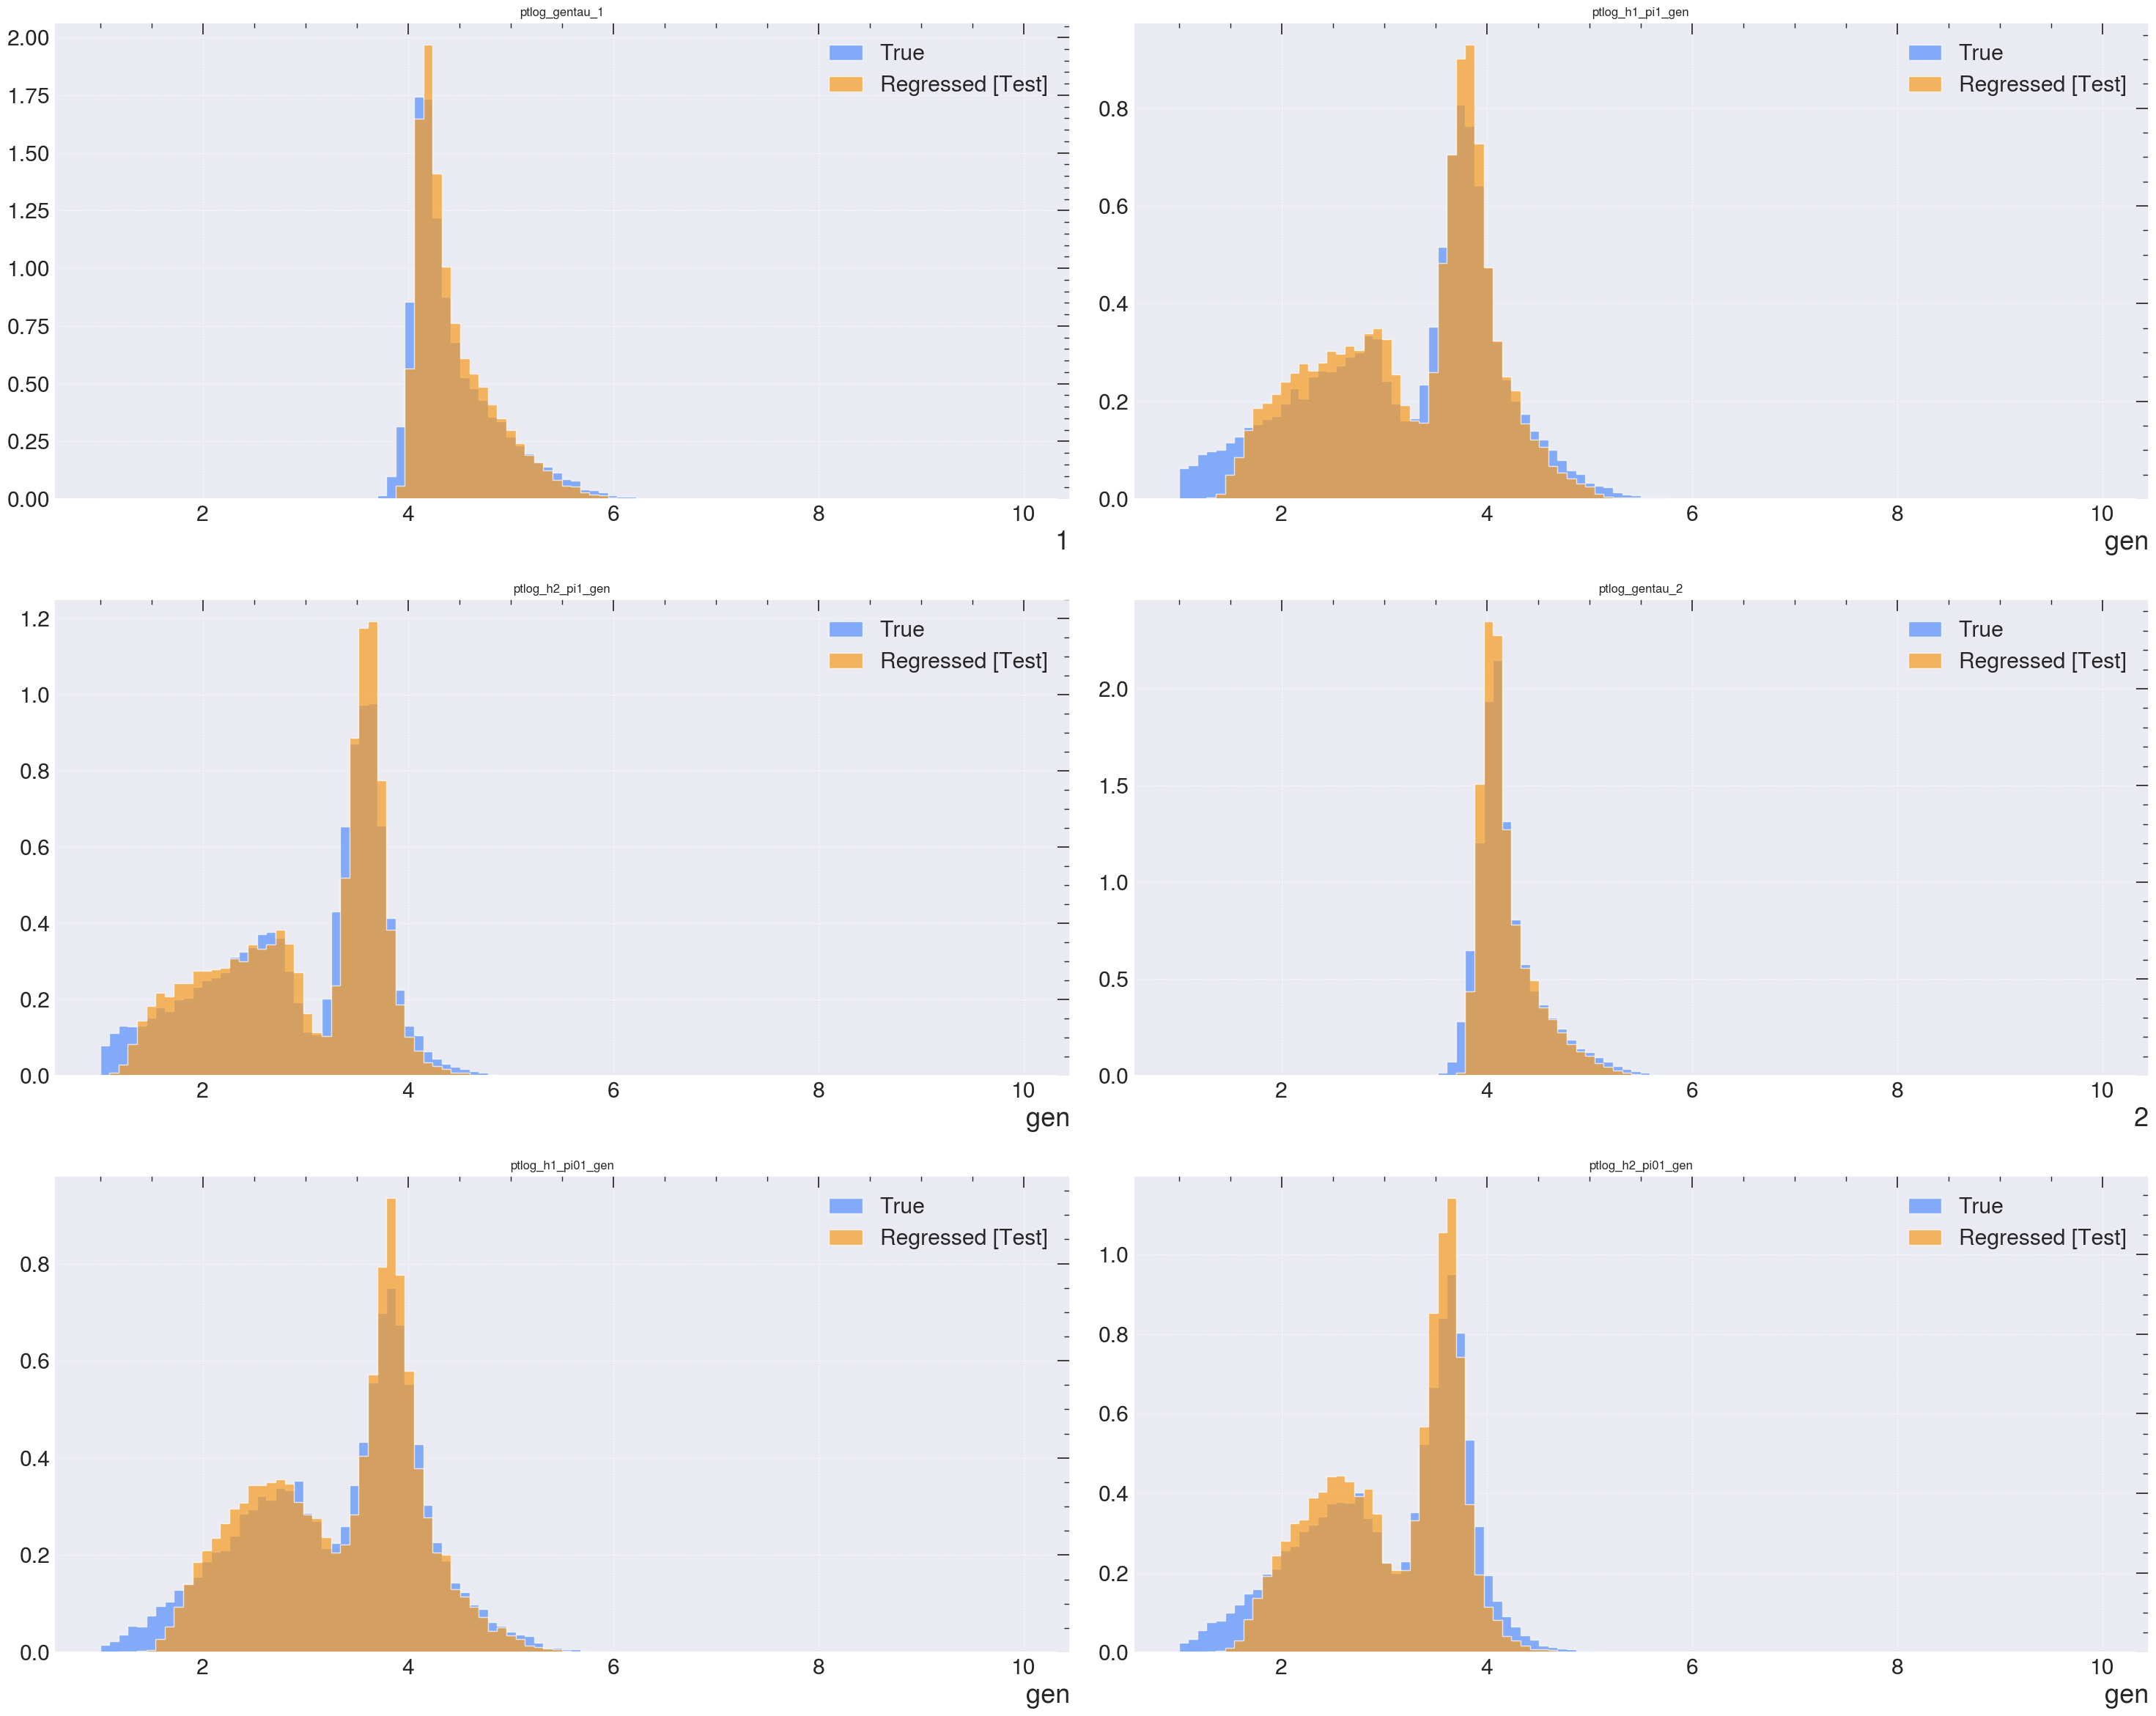

In [ ]:
plt.figure(figsize=(30,24))
for idx, key in enumerate(targets):
        idx=idx+1
        ax = plt.subplot(3,2,idx)
        arr_true = target_val_test[:,(idx-1):idx].reshape(-1)
        arr_pred = target_reg_val_test[:,(idx-1):idx].reshape(-1)

        #print(arr)

        # if idx == 1 or idx == 4:
        #         minmax = [1,10]
        # elif idx == 2 or idx == 5:
        #         minmax = [-3.5, 3.5]
        # else: 
        #         minmax = [-2, 2]

        if idx <=8 :
                minmax = [1,10]
        elif idx > 24 and idx <= 31:
                minmax = [1, 100]
        else: 
                minmax = [-2, 2]
        
        
        ax.hist(arr_true, 100, histtype="stepfilled", alpha=0.7, label='True', log=False, density=True,
                range=minmax)
        ax.hist(arr_pred, 100, histtype="stepfilled", alpha=0.7, label='Regressed [Test]', log=False, density=True,
                range=minmax)
                
        ax.set_title(f"{key}")
        ax.set_xlabel(f"""{key.split('_')[-1]}""")
        ax.legend()

pngname = os.path.join(tagdir,f'output_test_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.tight_layout()
plt.savefig(pngname, dpi=300)